In [ ]:
#   LOAD_FROM_SAVED - Set this FIRST before running the notebook
#
#   True  -> load pre-computed skip all training
#   False -> retrain every model from scratch

LOAD_FROM_SAVED = True
LOCAL_RUN = True

# -- Extract ZIP from Google Drive (teammates only) ---------------------------
# When LOAD_FROM_SAVED = True, this extracts the shared pkl files from Drive.
# When False or not on Colab, this cell is safely skipped.

import os

if LOAD_FROM_SAVED:
    # try:
    #     if LOCAL_RUN:
    #         zip_path = f"{os.getcwd()}/all_outputs.zip"
    #     else:
    #         from google.colab import drive
    #         drive.mount('/content/drive')
    #         zip_path = "/content/drive/MyDrive/all_outputs.zip"
            
    #     if os.path.exists(zip_path):
    #         import zipfile
    #         with zipfile.ZipFile(zip_path, "r") as zf:
    #             zf.extractall(".")
    #             print(f" Extracted {len(zf.namelist())} files from {zip_path}")
    #         print(" Files ready. Now just Run All - training cells are skipped automatically.")
    #     else:
    #         print(f" {zip_path} not found. If .pkl files are already in saved_models/, continue.")
    # except ImportError:
    #     print("(Not running on Colab - skipping Drive mount. Continue normally.)")
    pass
else:
    print("LOAD_FROM_SAVED = False -> Drive extraction skipped. Models will be trained from scratch.")

✓ Extracted 99 files from /scratch/HS401/repos/sentiment-analysis-and-sarcasm-detection/Additional Experiments/all_outputs.zip
✓ Files ready. Now just Run All — training cells are skipped automatically.


# Q2.1 - Classical Baseline vs. Fine-tuned Transformer for Sentiment & Sarcasm

- **Data:** All three varieties (en-AU, en-IN, en-UK) pooled into unified train/val/test splits.
- **Classical:** TF-IDF (unigram+bigram) -> Logistic Regression + Linear SVM, `class_weight='balanced'`
- **FastText:** Supervised classifier with autotuned hyperparameters, minority-class oversampling
- **Transformer:** `roberta-base` fine-tuned with weighted cross-entropy
- **Seeds:** 3 runs per setup (42, 123, 456), mean ± std reported
- **Metrics:** Macro-F1 (primary), Precision, Recall, per-class breakdown, confusion matrices

## 1. Setup & Installations

In [2]:
# Install required packages (run once)
%pip install datasets transformers accelerate scikit-learn matplotlib seaborn pandas numpy -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import random
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

from collections import Counter

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

import torch
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

SEEDS = [42, 123, 456]  # Three seeds for multiple runs
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "./saved_models"  # Directory for saving trained models and results
PLOTS_DIR = "./Results/plots"
CSV_DIR = "./Results/csv"
os.makedirs(SAVE_DIR, exist_ok=True)

# Q2.2 constants (defined here so they're available after loading from saved)
VARIETIES = ["en-AU", "en-IN", "en-UK"]
CROSS_SEEDS = [42, 123]  # Two seeds for cross-variety runs
CROSS_TASK = "Sentiment"

print(f"Using device: {DEVICE}")
print(f"Models will be saved to: {SAVE_DIR}")

Using device: cuda
Models will be saved to: ./saved_models


In [4]:
def set_seed(seed: int):
    """Set random seed for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## 2. Data Loading & Exploration

We load all three varieties from the BESSTIE dataset and **pool** them into unified splits. The pre-defined train/validation/test splits are respected - we never leak data across them.

In [5]:
# Load dataset (single config; variety is a column, not a config)
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)
print(f"\nColumns: {ds['train'].column_names}")
print(f"\nSample row:\n{ds['train'][0]}")

# Show per-variety counts
for split in ["train", "validation", "test"]:
    varieties = Counter(ds[split]["variety"])
    print(f"\n{split}: {dict(varieties)}")

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})

Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']

Sample row:
{'text': "I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'variety': 'en-UK', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 0.0}

train: {'en-UK': 1203, 'en-AU': 1145, 'en-IN': 1399}

validation: {'en-AU': 95, 'en-IN': 117, 'en-UK': 101}

test: {'en-AU': 667, 'en-UK': 700, 'en-IN': 816}


In [ ]:
# The dataset is already pooled across varieties in each split.
# We use it directly - no concatenation needed.
pooled = ds

print("Dataset sizes (all varieties pooled):")
for split in ["train", "validation", "test"]:
    print(f"  {split}: {len(pooled[split])} samples")

Dataset sizes (all varieties pooled):
  train: 3747 samples
  validation: 313 samples
  test: 2183 samples


In [7]:
# Column names (verified from the dataset card)
text_col = "text"
sentiment_col = "Sentiment"
sarcasm_col = "Sarcasm"

print(f"Text column    : {text_col}")
print(f"Sentiment column: {sentiment_col}")
print(f"Sarcasm column  : {sarcasm_col}")

Text column    : text
Sentiment column: Sentiment
Sarcasm column  : Sarcasm


In [8]:
# Class-distribution analysis
for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    print(f"\n=== {task_name} ({label_col}) ===")
    for split in ["train", "validation", "test"]:
        labels = pooled[split][label_col]
        counts = Counter(labels)
        total = len(labels)
        print(f"  {split:>10}: {dict(counts)}  (total={total}, "
              f"minority ratio={min(counts.values())/total:.2%})")


=== Sentiment (Sentiment) ===
       train: {0.0: 1907, 1.0: 1840}  (total=3747, minority ratio=49.11%)
  validation: {1.0: 153, 0.0: 160}  (total=313, minority ratio=48.88%)
        test: {1.0: 1066, 0.0: 1117}  (total=2183, minority ratio=48.83%)

=== Sarcasm (Sarcasm) ===
       train: {0.0: 3223, 1.0: 524}  (total=3747, minority ratio=13.98%)
  validation: {0.0: 269, 1.0: 44}  (total=313, minority ratio=14.06%)
        test: {0.0: 1878, 1.0: 305}  (total=2183, minority ratio=13.97%)


## Load Saved Results (Skip Training)

`LOAD_FROM_SAVED` is set in **Cell 1** at the very top of the notebook. When `True` (the default), the cell below loads all pre-computed results from `.pkl` files and **all training cells are automatically skipped** - just **Run All**.

To retrain from scratch, change `LOAD_FROM_SAVED = False` in Cell 1.

In [ ]:
# LOAD SAVED RESULTS - pkl files -> memory

if LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "classical_all_results.pkl"), "rb") as f:
        classical_all_results = pickle.load(f)
    with open(os.path.join(SAVE_DIR, "best_classical.pkl"), "rb") as f:
        best_classical = pickle.load(f)
    with open(os.path.join(SAVE_DIR, "transformer_all_results.pkl"), "rb") as f:
        transformer_all_results = pickle.load(f)

    print(" Q2.1 results loaded from saved_models/")
    print(f"  Classical tasks: {list(classical_all_results.keys())}")
    print(f"  Best classical:  {best_classical}")
    print(f"  Transformer tasks: {list(transformer_all_results.keys())}")

    # Load cross-variety results if available (Q2.2)
    cv_path = os.path.join(SAVE_DIR, "cross_variety_results.pkl")
    if os.path.exists(cv_path):
        with open(cv_path, "rb") as f:
            cross_variety_results = pickle.load(f)
        print(f"  Cross-variety results also loaded ({len(cross_variety_results)} runs)")
    else:
        print("  (Cross-variety results not found - run Q2.2 training if needed)")

    print("\n All results loaded. Training cells will be skipped automatically.")
else:
    print("LOAD_FROM_SAVED = False -> Training cells will run normally.")

✓ Q2.1 results loaded from saved_models/
  Classical tasks: ['Sentiment', 'Sarcasm']
  Best classical:  {'Sentiment': 'LinearSVM', 'Sarcasm': 'LogisticRegression'}
  Transformer tasks: ['Sentiment', 'Sarcasm']
  Cross-variety results also loaded (6 runs)

✓ All results loaded. Training cells will be skipped automatically.


## 3. Classical Baselines - TF-IDF + Logistic Regression / Linear SVM

### Design choices
- **TF-IDF** with unigrams + bigrams (`ngram_range=(1,2)`) and sublinear TF scaling to capture negation patterns ("not good").
- **Logistic Regression** with `class_weight='balanced'` to handle sarcasm class imbalance.
- **Linear SVM** (LinearSVC) with `class_weight='balanced'` as a second classical option.
- The TF-IDF vectorizer is **fit on training data only**; validation and test sets are transformed using the fitted vocabulary.

In [10]:
def run_classical_baseline(texts_train, y_train, texts_val, y_val,
                           texts_test, y_test, seed, task_name):
    """
    Run TF-IDF + Logistic Regression and TF-IDF + LinearSVC.
    Returns a dict of metrics for each classifier.
    """
    set_seed(seed)

    # Fit TF-IDF on training data only
    tfidf = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )
    X_train = tfidf.fit_transform(texts_train)
    X_val = tfidf.transform(texts_val)
    X_test = tfidf.transform(texts_test)

    results = {}

    # --- Logistic Regression ---
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=seed,
        solver='lbfgs',
    )
    lr.fit(X_train, y_train)

    # Measure inference time (TF-IDF transform + prediction)
    t0 = time.time()
    X_test_timed = tfidf.transform(texts_test)
    y_pred_lr = lr.predict(X_test_timed)
    lr_inference_ms = (time.time() - t0) * 1000
    avg_lr_ms = lr_inference_ms / len(texts_test)

    results['LogisticRegression'] = {
        'y_pred': y_pred_lr,
        'inference_time_total_ms': lr_inference_ms,
        'inference_time_per_sample_ms': avg_lr_ms,
        'macro_f1': f1_score(y_test, y_pred_lr, average='macro'),
        'macro_precision': precision_score(y_test, y_pred_lr, average='macro'),
        'macro_recall': recall_score(y_test, y_pred_lr, average='macro'),
        'report': classification_report(y_test, y_pred_lr, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred_lr),
    }

    # --- Linear SVM ---
    svm = LinearSVC(
        class_weight='balanced',
        max_iter=2000,
        random_state=seed,
    )
    svm.fit(X_train, y_train)

    # Measure inference time (TF-IDF transform + prediction)
    t0 = time.time()
    X_test_timed = tfidf.transform(texts_test)
    y_pred_svm = svm.predict(X_test_timed)
    svm_inference_ms = (time.time() - t0) * 1000
    avg_svm_ms = svm_inference_ms / len(texts_test)

    results['LinearSVM'] = {
        'y_pred': y_pred_svm,
        'inference_time_total_ms': svm_inference_ms,
        'inference_time_per_sample_ms': avg_svm_ms,
        'macro_f1': f1_score(y_test, y_pred_svm, average='macro'),
        'macro_precision': precision_score(y_test, y_pred_svm, average='macro'),
        'macro_recall': recall_score(y_test, y_pred_svm, average='macro'),
        'report': classification_report(y_test, y_pred_svm, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred_svm),
    }

    # Save models to disk for later reuse
    save_path = os.path.join(SAVE_DIR, f"classical_{task_name.lower()}_seed{seed}")
    os.makedirs(save_path, exist_ok=True)
    joblib.dump(tfidf, os.path.join(save_path, "tfidf.joblib"))
    joblib.dump(lr, os.path.join(save_path, "lr.joblib"))
    joblib.dump(svm, os.path.join(save_path, "svm.joblib"))
    print(f"    Classical models saved to {save_path}")

    return results

In [ ]:
# Run classical baselines for BOTH tasks, across multiple seeds
if not LOAD_FROM_SAVED:
    classical_all_results = {}  # {task: {classifier: [{run_metrics}, ...]}}

    for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
        print(f"\n{'='*60}")
        print(f"CLASSICAL BASELINES - {task_name.upper()} TASK")
        print(f"{'='*60}")

        texts_train = pooled['train'][text_col]
        y_train = pooled['train'][label_col]
        texts_val = pooled['validation'][text_col]
        y_val = pooled['validation'][label_col]
        texts_test = pooled['test'][text_col]
        y_test = pooled['test'][label_col]

        classical_all_results[task_name] = {'LogisticRegression': [], 'LinearSVM': []}

        for seed in SEEDS:
            print(f"\n  Seed={seed}")
            res = run_classical_baseline(
                texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name
            )
            for clf_name in ['LogisticRegression', 'LinearSVM']:
                m = res[clf_name]
                classical_all_results[task_name][clf_name].append(m)
                print(f"    {clf_name}: Macro-F1={m['macro_f1']:.4f}  "
                      f"P={m['macro_precision']:.4f}  R={m['macro_recall']:.4f}  "
                      f"Inference: {m['inference_time_total_ms']:.1f}ms total, "
                      f"{m['inference_time_per_sample_ms']:.3f}ms/sample")
else:
    print("⏭ Skipping classical baseline training (results loaded from pkl files)")

⏭ Skipping classical baseline training (results loaded from pkl files)


In [12]:
# Summarise classical results: mean ± std
print("\n" + "="*70)
print("CLASSICAL BASELINE SUMMARY (mean ± std over 3 seeds)")
print("="*70)

classical_summary = []

for task_name in ["Sentiment", "Sarcasm"]:
    for clf_name in ['LogisticRegression', 'LinearSVM']:
        runs = classical_all_results[task_name][clf_name]
        f1s = [r['macro_f1'] for r in runs]
        ps  = [r['macro_precision'] for r in runs]
        rs  = [r['macro_recall'] for r in runs]
        row = {
            'Task': task_name,
            'Model': clf_name,
            'Macro-F1': f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
            'Precision': f"{np.mean(ps):.4f} ± {np.std(ps):.4f}",
            'Recall': f"{np.mean(rs):.4f} ± {np.std(rs):.4f}",
            'f1_mean': np.mean(f1s),
        }
        classical_summary.append(row)
        print(f"  {task_name:>10} | {clf_name:<20} | F1={row['Macro-F1']}  "
              f"P={row['Precision']}  R={row['Recall']}")

# Pick the best classical model per task
best_classical = {}
for task_name in ["Sentiment", "Sarcasm"]:
    task_rows = [r for r in classical_summary if r['Task'] == task_name]
    best_row = max(task_rows, key=lambda r: r['f1_mean'])
    best_classical[task_name] = best_row['Model']
    print(f"\n  Best classical for {task_name}: {best_row['Model']}")


CLASSICAL BASELINE SUMMARY (mean ± std over 3 seeds)
   Sentiment | LogisticRegression   | F1=0.8287 ± 0.0000  P=0.8300 ± 0.0000  R=0.8285 ± 0.0000
   Sentiment | LinearSVM            | F1=0.8407 ± 0.0000  P=0.8418 ± 0.0000  R=0.8404 ± 0.0000
     Sarcasm | LogisticRegression   | F1=0.6275 ± 0.0000  P=0.6143 ± 0.0000  R=0.6688 ± 0.0000
     Sarcasm | LinearSVM            | F1=0.5932 ± 0.0000  P=0.6103 ± 0.0000  R=0.5838 ± 0.0000

  Best classical for Sentiment: LinearSVM

  Best classical for Sarcasm: LogisticRegression


In [ ]:
# -- Save classical results to disk --------------------------------------------
if not LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "classical_all_results.pkl"), "wb") as f:
        pickle.dump(classical_all_results, f)
    with open(os.path.join(SAVE_DIR, "best_classical.pkl"), "wb") as f:
        pickle.dump(best_classical, f)
    print(f" Classical results saved to {SAVE_DIR}/")
else:
    print("⏭ Skipping save (results already on disk)")

⏭ Skipping save (results already on disk)


## 3b. FastText Baseline - Shallow Word Embeddings

- **FastText supervised** learns task-specific word embeddings with subword character n-grams
- Sits **between** TF-IDF (sparse, no learned representations) and RoBERTa (deep contextual)
- Subword approach handles OOV words and slang (relevant for en-AU/en-IN)
- `autotuneDuration=120` searches hyperparameters on validation set
- **Class imbalance:** FastText has no `class_weight='balanced'` -> we oversample the minority class in training data. Val/test left unbalanced.

In [14]:
%pip install fasttext-wheel -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import fasttext
import tempfile

def run_fasttext_baseline(texts_train, y_train, texts_val, y_val,
                          texts_test, y_test, seed, task_name):
    """
    Train FastText supervised classifier and evaluate on test set.
    Returns a dict of metrics matching the classical baseline format.
    """
    set_seed(seed)

    def write_fasttext_file(texts, labels, filepath, oversample_minority=False, seed=42):
        """Write texts/labels in fasttext format. Optionally oversample minority class."""
        text_label_pairs = list(zip(texts, labels))

        if oversample_minority:
            # Separate majority and minority classes
            from collections import Counter
            counts = Counter(int(l) for _, l in text_label_pairs)
            majority_label = max(counts, key=counts.get)
            minority_label = min(counts, key=counts.get)
            n_majority = counts[majority_label]
            n_minority = counts[minority_label]

            if n_minority < n_majority:
                majority_pairs = [(t, l) for t, l in text_label_pairs if int(l) == majority_label]
                minority_pairs = [(t, l) for t, l in text_label_pairs if int(l) == minority_label]

                # Oversample minority to match majority count
                rng = random.Random(seed)
                extra = [minority_pairs[rng.randint(0, len(minority_pairs)-1)]
                         for _ in range(n_majority - n_minority)]
                text_label_pairs = majority_pairs + minority_pairs + extra
                rng.shuffle(text_label_pairs)

        with open(filepath, 'w', encoding='utf-8') as f:
            for text, label in text_label_pairs:
                clean = ' '.join(str(text).replace('\n', ' ').split())
                f.write(f'__label__{int(label)} {clean}\n')

    # Create temporary files for train and validation
    with tempfile.TemporaryDirectory() as tmpdir:
        train_path = os.path.join(tmpdir, 'train.txt')
        val_path   = os.path.join(tmpdir, 'val.txt')

        # Oversample minority class in training data to handle class imbalance
        write_fasttext_file(texts_train, y_train, train_path,
                            oversample_minority=True, seed=seed)
        write_fasttext_file(texts_val, y_val, val_path,
                            oversample_minority=False)

        # Train with autotuning on validation set
        # autotuneDuration controls how long (seconds) to search hyperparameters
        model = fasttext.train_supervised(
            input=train_path,
            autotuneValidationFile=val_path,
            autotuneDuration=120,       # 2 minutes of hyperparameter search per run
            seed=seed,
            verbose=0,
        )

    # Predict on test set and measure inference time
    t0 = time.time()
    y_pred = []
    for text in texts_test:
        clean = ' '.join(str(text).replace('\n', ' ').split())
        try:
            pred_labels, _ = model.predict(clean)
        except ValueError:
            # NumPy 2.x workaround: call internal predict and extract labels
            pairs = model.f.predict(clean, 1, 0.0, 'strict')
            if pairs:
                _, pred_labels = zip(*pairs)
            else:
                pred_labels = ('__label__0',)
        y_pred.append(int(pred_labels[0].replace('__label__', '')))
    inference_ms = (time.time() - t0) * 1000
    avg_ms = inference_ms / len(texts_test)

    y_pred = np.array(y_pred)
    y_test_arr = np.array(y_test)

    result = {
        'y_pred': y_pred,
        'inference_time_total_ms': inference_ms,
        'inference_time_per_sample_ms': avg_ms,
        'macro_f1': f1_score(y_test_arr, y_pred, average='macro'),
        'macro_precision': precision_score(y_test_arr, y_pred, average='macro'),
        'macro_recall': recall_score(y_test_arr, y_pred, average='macro'),
        'report': classification_report(y_test_arr, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test_arr, y_pred),
    }

    # Save model
    save_path = os.path.join(SAVE_DIR, f"fasttext_{task_name.lower()}_seed{seed}")
    os.makedirs(save_path, exist_ok=True)
    model_file = os.path.join(save_path, "model.bin")
    model.save_model(model_file)
    print(f"    FastText model saved to {model_file}")

    return result

print(" run_fasttext_baseline() defined (with minority oversampling)")

✓ run_fasttext_baseline() defined (with minority oversampling)


In [ ]:
# Run FastText for BOTH tasks, across multiple seeds
FASTTEXT_PKL = os.path.join(SAVE_DIR, "fasttext_results.pkl")

if os.path.exists(FASTTEXT_PKL):
    # Load previously saved FastText results
    with open(FASTTEXT_PKL, "rb") as f:
        fasttext_results = pickle.load(f)
    # Merge into classical_all_results
    for task_name in ["Sentiment", "Sarcasm"]:
        if task_name in fasttext_results:
            classical_all_results[task_name]['FastText'] = fasttext_results[task_name]
    print(f" FastText results loaded from {FASTTEXT_PKL}")
else:
    # Train FastText from scratch
    fasttext_results = {}

    for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
        print(f"\n{'='*60}")
        print(f"FASTTEXT BASELINE - {task_name.upper()} TASK")
        print(f"{'='*60}")

        texts_train = pooled['train'][text_col]
        y_train = pooled['train'][label_col]
        texts_val = pooled['validation'][text_col]
        y_val = pooled['validation'][label_col]
        texts_test = pooled['test'][text_col]
        y_test = pooled['test'][label_col]

        fasttext_results[task_name] = []

        for seed in SEEDS:
            print(f"\n  Seed={seed} (autotuning for 120s ...)")
            res = run_fasttext_baseline(
                texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name
            )
            fasttext_results[task_name].append(res)
            print(f"    FastText: Macro-F1={res['macro_f1']:.4f}  "
                  f"P={res['macro_precision']:.4f}  R={res['macro_recall']:.4f}  "
                  f"Inference: {res['inference_time_total_ms']:.1f}ms total, "
                  f"{res['inference_time_per_sample_ms']:.3f}ms/sample")

        # Also add to classical_all_results for downstream cells
        classical_all_results[task_name]['FastText'] = fasttext_results[task_name]

    # Save FastText results separately (so they persist across LOAD_FROM_SAVED)
    with open(FASTTEXT_PKL, "wb") as f:
        pickle.dump(fasttext_results, f)
    print(f"\n FastText results saved to {FASTTEXT_PKL}")

✓ FastText results loaded from ./saved_models/fasttext_results.pkl


In [17]:
# Summarise FastText results: mean ± std
print("\n" + "="*70)
print("FASTTEXT SUMMARY (mean ± std over 3 seeds)")
print("="*70)

for task_name in ["Sentiment", "Sarcasm"]:
    if 'FastText' not in classical_all_results.get(task_name, {}):
        print(f"  {task_name}: FastText not available"); continue
    runs = classical_all_results[task_name]['FastText']
    f1s = [r['macro_f1'] for r in runs]
    ps  = [r['macro_precision'] for r in runs]
    rs  = [r['macro_recall'] for r in runs]
    print(f"  {task_name:>10} | FastText | "
          f"F1={np.mean(f1s):.4f} ± {np.std(f1s):.4f}  "
          f"P={np.mean(ps):.4f} ± {np.std(ps):.4f}  "
          f"R={np.mean(rs):.4f} ± {np.std(rs):.4f}")


FASTTEXT SUMMARY (mean ± std over 3 seeds)
   Sentiment | FastText | F1=0.8066 ± 0.0241  P=0.8079 ± 0.0235  R=0.8074 ± 0.0239
     Sarcasm | FastText | F1=0.5957 ± 0.0185  P=0.6108 ± 0.0063  R=0.6054 ± 0.0468


In [ ]:
# Per-class breakdown for FastText (seed index 0)
# Define task_target_names here (also defined in cell 18/26 - harmless redefinition)
task_target_names = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm':   ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    if 'FastText' not in classical_all_results.get(task_name, {}):
        continue
    best_run = classical_all_results[task_name]['FastText'][0]  # first seed
    y_test = pooled['test'][label_col]

    print(f"\n{'='*50}")
    print(f"{task_name} - FastText - Per-Class Report (seed={SEEDS[0]})")
    print("="*50)
    print(classification_report(y_test, best_run['y_pred'],
                                target_names=task_target_names[task_name]))


Sentiment — FastText — Per-Class Report (seed=42)
              precision    recall  f1-score   support

Negative (0)       0.81      0.75      0.78      1117
Positive (1)       0.75      0.81      0.78      1066

    accuracy                           0.78      2183
   macro avg       0.78      0.78      0.78      2183
weighted avg       0.78      0.78      0.78      2183


Sarcasm — FastText — Per-Class Report (seed=42)
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.92      0.79      0.85      1878
    Sarcastic (1)       0.30      0.55      0.39       305

         accuracy                           0.76      2183
        macro avg       0.61      0.67      0.62      2183
     weighted avg       0.83      0.76      0.79      2183



In [ ]:
# Per-class breakdown for best classical seed (seed index 0) per task
task_target_names = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm':   ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    best_run = classical_all_results[task_name][clf_name][0]  # first seed
    y_test = pooled['test'][label_col]

    print(f"\n{'='*50}")
    print(f"{task_name} - {clf_name} - Per-Class Report (seed={SEEDS[0]})")
    print("="*50)
    print(classification_report(y_test, best_run['y_pred'],
                                target_names=task_target_names[task_name]))


Sentiment — LinearSVM — Per-Class Report (seed=42)
              precision    recall  f1-score   support

Negative (0)       0.83      0.87      0.85      1117
Positive (1)       0.85      0.81      0.83      1066

    accuracy                           0.84      2183
   macro avg       0.84      0.84      0.84      2183
weighted avg       0.84      0.84      0.84      2183


Sarcasm — LogisticRegression — Per-Class Report (seed=42)
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.91      0.82      0.86      1878
    Sarcastic (1)       0.32      0.52      0.39       305

         accuracy                           0.78      2183
        macro avg       0.61      0.67      0.63      2183
     weighted avg       0.83      0.78      0.80      2183



## 3c. Class Imbalance Handling - Oversampling vs Class Weighting

The sarcasm task exhibits severe class imbalance, with sarcastic instances
representing a small minority of the training data. This section investigates
the effect of three different strategies for handling this imbalance using
**TF-IDF + Logistic Regression** as the base classifier:

1. **No balancing** - train on the raw imbalanced data as a reference point
2. **Class weighting** - assign higher loss penalty to the minority class
   via `class_weight='balanced'`
3. **Random oversampling** - duplicate minority-class samples in the training
   set until both classes are equal in size

All three strategies are evaluated on the **unmodified test set** to ensure
fair comparison. Results are averaged over 3 seeds to account for randomness.

### 3c1. Helper Function

In [20]:
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)

def run_logreg_balance_comparison(train_df, val_df, test_df, text_col, label_col, seed=42):
    """
    Compare three training setups for TF-IDF + Logistic Regression:
    1. No balancing
    2. Class weighting
    3. Random oversampling (training only)

    Returns a DataFrame of summary metrics and a dict of detailed outputs.
    """
    # -----------------------------
    # Prepare raw text/labels
    # -----------------------------
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    X_train_text = train_df[text_col].astype(str)
    y_train = train_df[label_col].astype(int)

    X_test_text = test_df[text_col].astype(str)
    y_test = test_df[label_col].astype(int)

    # -----------------------------
    # Shared evaluation helper
    # -----------------------------
    def evaluate(name, clf, vectorizer, X_test_text, y_test):
        X_test = vectorizer.transform(X_test_text)
        y_pred = clf.predict(X_test)

        result = {
            "setting": name,
            "macro_f1": f1_score(y_test, y_pred, average="macro"),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_non_sarcastic": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
            "f1_sarcastic": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            "report": classification_report(
                y_test, y_pred,
                target_names=["Non-Sarcastic", "Sarcastic"],
                zero_division=0
            ),
            "cm": confusion_matrix(y_test, y_pred)
        }
        return result

    detailed_results = {}

    # -----------------------------
    # 1) No balancing
    # -----------------------------
    vec_none = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )
    X_train_none = vec_none.fit_transform(X_train_text)

    clf_none = LogisticRegression(
        max_iter=1000,
        random_state=seed,
        solver="lbfgs"
    )
    clf_none.fit(X_train_none, y_train)
    detailed_results["No balancing"] = evaluate("No balancing", clf_none, vec_none, X_test_text, y_test)

    # -----------------------------
    # 2) Class weighting
    # -----------------------------
    vec_weight = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )
    X_train_weight = vec_weight.fit_transform(X_train_text)

    clf_weight = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=seed,
        solver="lbfgs"
    )
    clf_weight.fit(X_train_weight, y_train)
    detailed_results["Class weighting"] = evaluate("Class weighting", clf_weight, vec_weight, X_test_text, y_test)

    # -----------------------------
    # 3) Random oversampling (train only)
    # -----------------------------
    counts = train_df[label_col].value_counts()
    majority_label = counts.idxmax()
    minority_label = counts.idxmin()

    majority_df = train_df[train_df[label_col] == majority_label]
    minority_df = train_df[train_df[label_col] == minority_label]

    minority_up = resample(
        minority_df,
        replace=True,
        n_samples=len(majority_df),
        random_state=seed
    )

    train_over = pd.concat([majority_df, minority_up], axis=0) \
                   .sample(frac=1, random_state=seed) \
                   .reset_index(drop=True)

    X_train_over_text = train_over[text_col].astype(str)
    y_train_over = train_over[label_col].astype(int)

    vec_over = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
    )
    X_train_over = vec_over.fit_transform(X_train_over_text)

    clf_over = LogisticRegression(
        max_iter=1000,
        random_state=seed,
        solver="lbfgs"
    )
    clf_over.fit(X_train_over, y_train_over)
    detailed_results["Oversampling"] = evaluate("Oversampling", clf_over, vec_over, X_test_text, y_test)

    # -----------------------------
    # Summary table
    # -----------------------------
    summary_rows = []
    for k, v in detailed_results.items():
        summary_rows.append({
            "setting": k,
            "macro_f1": v["macro_f1"],
            "precision_macro": v["precision_macro"],
            "recall_macro": v["recall_macro"],
            "accuracy": v["accuracy"],
            "f1_non_sarcastic": v["f1_non_sarcastic"],
            "f1_sarcastic": v["f1_sarcastic"]
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
    return summary_df, detailed_results

### 3c2. Run Comparison on Sarcasm

In [ ]:
# Oversampling vs class weighting mini-experiment
# Use Sarcasm only, with Logistic Regression

all_seed_results = {}
all_seed_summaries = [] # collect per seed summaries

train_df = pooled["train"].to_pandas()
val_df = pooled["validation"].to_pandas()
test_df = pooled["test"].to_pandas()

for seed in SEEDS:
    balance_summary_df, balance_details = run_logreg_balance_comparison(
        train_df, val_df, test_df, text_col, sarcasm_col, seed=seed
    )
    print(f"\n=== Seed {seed} ===")
    display(balance_summary_df)
    all_seed_results[seed] = balance_details
    
    # Save per seed result
    balance_summary_df['seed'] = seed
    all_seed_summaries.append(balance_summary_df)
    
pd.concat(all_seed_summaries, ignore_index=True).to_csv(f'{CSV_DIR}/balancing_per_seed_results.csv', index=False)

# Aggregate across seeds for the chart
settings = ['No balancing', 'Class weighting', 'Oversampling']
agg = {s: {'macro_f1': [], 'f1_sarcastic': []} for s in settings}

for seed, details in all_seed_results.items():
    for setting in settings:
        agg[setting]['macro_f1'].append(details[setting]['macro_f1'])
        agg[setting]['f1_sarcastic'].append(details[setting]['f1_sarcastic'])

# Print detailed report for one representative seed only
# Note: summary metrics above are averaged across all seeds
REPORT_SEED = SEEDS[0]  # seed=42 used as representative example
balance_details = all_seed_results[REPORT_SEED]
print(f"\n{'='*70}")
print(f"DETAILED CLASSIFICATION REPORTS - Seed {REPORT_SEED} (representative)")
print("Note: Macro-F1 summary above is averaged across all seeds.")

# Save detailed classification reports 
report_rows = []
for setting, info in balance_details.items():
    print("\n" + "=" * 70)
    print(setting)
    print("=" * 70)
    print(info["report"])
    print("Confusion matrix:")
    print(info["cm"])
    report_rows.append({
        'seed': REPORT_SEED,
        'setting': setting,
        'precision_non_sarcastic': info['cm'][0][0] / (info['cm'][0][0] + info['cm'][1][0]) if (info['cm'][0][0] + info['cm'][1][0]) > 0 else 0,
        'recall_non_sarcastic': info['cm'][0][0] / (info['cm'][0][0] + info['cm'][0][1]) if (info['cm'][0][0] + info['cm'][0][1]) > 0 else 0,
        'precision_sarcastic': info['cm'][1][1] / (info['cm'][0][1] + info['cm'][1][1]) if (info['cm'][0][1] + info['cm'][1][1]) > 0 else 0,
        'recall_sarcastic': info['cm'][1][1] / (info['cm'][1][0] + info['cm'][1][1]) if (info['cm'][1][0] + info['cm'][1][1]) > 0 else 0,
        'tn': info['cm'][0][0],
        'fp': info['cm'][0][1],
        'fn': info['cm'][1][0],
        'tp': info['cm'][1][1],
        'macro_f1': info['macro_f1'], }) 

pd.DataFrame(report_rows).to_csv(f'{CSV_DIR}/balancing_detailed_report.csv', index=False)


=== Seed 42 ===


,setting,macro_f1,precision_macro,recall_macro,accuracy,f1_non_sarcastic,f1_sarcastic
0,Class weighting,0.627520,0.614260,0.668803,0.775080,0.861962,0.393078
1,Oversampling,0.618262,0.618756,0.617776,0.817224,0.893855,0.342669
2,No balancing,0.462448,0.430142,0.500000,0.860284,0.924895,0.000000



=== Seed 123 ===


,setting,macro_f1,precision_macro,recall_macro,accuracy,f1_non_sarcastic,f1_sarcastic
0,Class weighting,0.627520,0.614260,0.668803,0.775080,0.861962,0.393078
1,Oversampling,0.613589,0.612391,0.614848,0.812185,0.890608,0.336570
2,No balancing,0.462448,0.430142,0.500000,0.860284,0.924895,0.000000



=== Seed 456 ===


,setting,macro_f1,precision_macro,recall_macro,accuracy,f1_non_sarcastic,f1_sarcastic
0,Class weighting,0.627520,0.614260,0.668803,0.775080,0.861962,0.393078
1,Oversampling,0.614821,0.612764,0.617061,0.811269,0.889898,0.339744
2,No balancing,0.462448,0.430142,0.500000,0.860284,0.924895,0.000000



DETAILED CLASSIFICATION REPORTS — Seed 42 (representative)
Note: Macro-F1 summary above is averaged across all seeds.

No balancing
               precision    recall  f1-score   support

Non-Sarcastic       0.86      1.00      0.92      1878
    Sarcastic       0.00      0.00      0.00       305

     accuracy                           0.86      2183
    macro avg       0.43      0.50      0.46      2183
 weighted avg       0.74      0.86      0.80      2183

Confusion matrix:
[[1878    0]
 [ 305    0]]

Class weighting
               precision    recall  f1-score   support

Non-Sarcastic       0.91      0.82      0.86      1878
    Sarcastic       0.32      0.52      0.39       305

     accuracy                           0.78      2183
    macro avg       0.61      0.67      0.63      2183
 weighted avg       0.83      0.78      0.80      2183

Confusion matrix:
[[1533  345]
 [ 146  159]]

Oversampling
               precision    recall  f1-score   support

Non-Sarcastic       0.89

### 3c3. Aggregated Results Summary

In [22]:
# Aggregated summary table across all seeds
summary_rows = []
for setting in settings:
    summary_rows.append({
        'Setting': setting,
        'Macro-F1 (mean)': round(np.mean(agg[setting]['macro_f1']), 4),
        'Macro-F1 (std)':  round(np.std(agg[setting]['macro_f1']), 4),
        'F1 Sarcastic (mean)': round(np.mean(agg[setting]['f1_sarcastic']), 4),
        'F1 Sarcastic (std)':  round(np.std(agg[setting]['f1_sarcastic']), 4),
    })

agg_summary_df = pd.DataFrame(summary_rows)
print("=== Balancing Strategy Summary (mean ± std over 3 seeds) ===")
display(agg_summary_df)
agg_summary_df.to_csv(f'{CSV_DIR}/balancing_strategy_summary.csv', index=False)

=== Balancing Strategy Summary (mean ± std over 3 seeds) ===


,Setting,Macro-F1 (mean),Macro-F1 (std),F1 Sarcastic (mean),F1 Sarcastic (std)
0,No balancing,0.4624,0.000,0.0000,0.0000
1,Class weighting,0.6275,0.000,0.3931,0.0000
2,Oversampling,0.6156,0.002,0.3397,0.0025


### 3c4. Results Visualisation

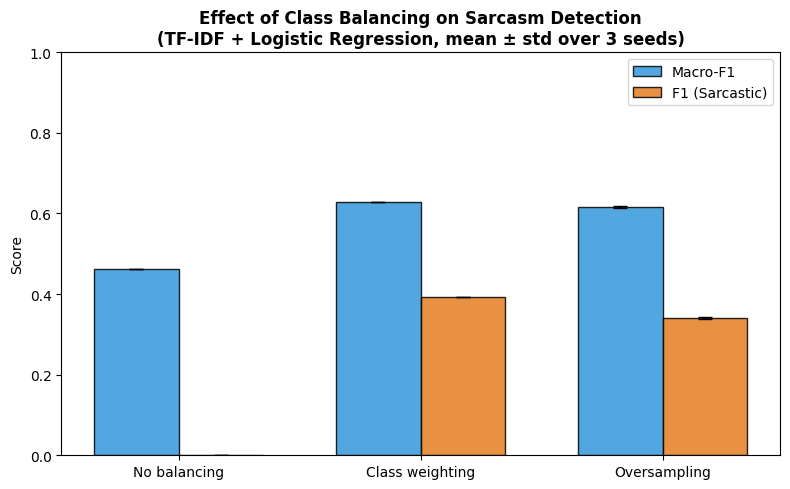

In [23]:
# Bar chart comparing balancing strategies
fig, ax = plt.subplots(figsize=(8, 5))

mean_f1 = [np.mean(agg[s]['macro_f1']) for s in settings]
std_f1 = [np.std(agg[s]['macro_f1']) for s in settings]
mean_sarc = [np.mean(agg[s]['f1_sarcastic']) for s in settings]
std_sarc = [np.std(agg[s]['f1_sarcastic']) for s in settings]

x = np.arange(len(settings))
width = 0.35

ax.bar(x - width/2, mean_f1, width, yerr=std_f1, label='Macro-F1',
       color='#3498db', edgecolor='black', alpha=0.85, capsize=5)
ax.bar(x + width/2, mean_sarc, width, yerr=std_sarc, label='F1 (Sarcastic)',
       color='#e67e22', edgecolor='black', alpha=0.85, capsize=5)

ax.set_xticks(x)
ax.set_xticklabels(settings)
ax.set_ylabel('Score')
ax.set_title('Effect of Class Balancing on Sarcasm Detection\n(TF-IDF + Logistic Regression, mean ± std over 3 seeds)',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/balancing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Fine-tuned Transformer - RoBERTa-base

### Design choices
- **Model:** `roberta-base` (125M parameters) with a linear classification head.
- **Class imbalance:** Weighted cross-entropy loss where class weights are inversely proportional to class frequencies in the training set.
- **Hyperparameters:** Learning rate = 2e-5, batch size = 16, max 5 epochs with early stopping on validation Macro-F1.
- **Validation:** The validation split is used for checkpoint selection and early stopping.
- **Multiple runs:** 3 seeds (affecting dropout, data shuffle, classification-head init).

In [24]:
# Custom Dataset for RoBERTa
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [25]:
from sklearn.utils.class_weight import compute_class_weight

def compute_metrics_for_trainer(eval_pred):
    """Compute metrics used by HuggingFace Trainer during evaluation."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'macro_f1': f1_score(labels, preds, average='macro'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro'),
    }


class WeightedTrainer(Trainer):
    """Custom Trainer that uses weighted cross-entropy loss for class imbalance."""
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = torch.nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [26]:
def run_roberta(texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name):
    """
    Fine-tune roberta-base for binary classification.
    Returns dict with predictions and metrics on the test set.
    """
    set_seed(seed)

    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=2
    ).to(DEVICE)

    train_ds = TextClassificationDataset(texts_train, y_train, tokenizer)
    val_ds   = TextClassificationDataset(texts_val,   y_val,   tokenizer)
    test_ds  = TextClassificationDataset(texts_test,  y_test,  tokenizer)

    # Compute class weights
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(y_train))
    print(f"    Class weights: {cw}")

    output_dir = f"./roberta_{task_name.lower()}_seed{seed}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=1,
        logging_steps=50,
        seed=seed,
        fp16=torch.cuda.is_available(),
        report_to='none',
    )

    trainer = WeightedTrainer(
        class_weights=cw,
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics_for_trainer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # Evaluate on test set and measure inference time
    t0 = time.time()
    preds_output = trainer.predict(test_ds)
    roberta_inference_ms = (time.time() - t0) * 1000
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    avg_roberta_ms = roberta_inference_ms / len(y_test)

    result = {
        'y_pred': y_pred,
        'inference_time_total_ms': roberta_inference_ms,
        'inference_time_per_sample_ms': avg_roberta_ms,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'macro_precision': precision_score(y_test, y_pred, average='macro'),
        'macro_recall': recall_score(y_test, y_pred, average='macro'),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
    }

    # Save the best model and tokenizer for later reuse
    save_path = os.path.join(SAVE_DIR, f"roberta_{task_name.lower()}_seed{seed}")
    os.makedirs(save_path, exist_ok=True)
    trainer.model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f"    Model saved to {save_path}")

    # Cleanup training checkpoints (keep only the saved model)
    import shutil
    if os.path.exists(output_dir) and os.path.abspath(output_dir) != os.path.abspath(save_path):
        shutil.rmtree(output_dir)

    return result

In [ ]:
# Run RoBERTa for BOTH tasks, across multiple seeds
if not LOAD_FROM_SAVED:
    transformer_all_results = {}  # {task: [{run_metrics}, ...]}

    for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
        print(f"\n{'='*60}")
        print(f"ROBERTA FINE-TUNING - {task_name.upper()} TASK")
        print(f"{'='*60}")

        texts_train = pooled['train'][text_col]
        y_train = pooled['train'][label_col]
        texts_val = pooled['validation'][text_col]
        y_val = pooled['validation'][label_col]
        texts_test = pooled['test'][text_col]
        y_test = pooled['test'][label_col]

        transformer_all_results[task_name] = []

        for seed in SEEDS:
            print(f"\n  --- Seed={seed} ---")
            res = run_roberta(
                texts_train, y_train, texts_val, y_val,
                texts_test, y_test, seed, task_name
            )
            transformer_all_results[task_name].append(res)
            print(f"    Test Macro-F1={res['macro_f1']:.4f}  "
                  f"P={res['macro_precision']:.4f}  R={res['macro_recall']:.4f}  "
                  f"Inference: {res['inference_time_total_ms']:.1f}ms total, "
                  f"{res['inference_time_per_sample_ms']:.3f}ms/sample")
else:
    print("⏭ Skipping RoBERTa training (results loaded from pkl files)")

⏭ Skipping RoBERTa training (results loaded from pkl files)


In [28]:
# Summarise Transformer results: mean ± std
print("\n" + "="*70)
print("ROBERTA FINE-TUNED SUMMARY (mean ± std over 3 seeds)")
print("="*70)

transformer_summary = []

for task_name in ["Sentiment", "Sarcasm"]:
    runs = transformer_all_results[task_name]
    f1s = [r['macro_f1'] for r in runs]
    ps  = [r['macro_precision'] for r in runs]
    rs  = [r['macro_recall'] for r in runs]
    row = {
        'Task': task_name,
        'Model': 'RoBERTa-base',
        'Macro-F1': f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
        'Precision': f"{np.mean(ps):.4f} ± {np.std(ps):.4f}",
        'Recall': f"{np.mean(rs):.4f} ± {np.std(rs):.4f}",
        'f1_mean': np.mean(f1s),
    }
    transformer_summary.append(row)
    print(f"  {task_name:>10} | RoBERTa-base | F1={row['Macro-F1']}  "
          f"P={row['Precision']}  R={row['Recall']}")


ROBERTA FINE-TUNED SUMMARY (mean ± std over 3 seeds)
   Sentiment | RoBERTa-base | F1=0.8915 ± 0.0054  P=0.8917 ± 0.0054  R=0.8916 ± 0.0053
     Sarcasm | RoBERTa-base | F1=0.7004 ± 0.0096  P=0.6805 ± 0.0093  R=0.7365 ± 0.0124


In [ ]:
# -- Save transformer results to disk ------------------------------------------
if not LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "transformer_all_results.pkl"), "wb") as f:
        pickle.dump(transformer_all_results, f)
    print(f" Transformer results saved to {SAVE_DIR}/")
else:
    print("⏭ Skipping save (results already on disk)")

⏭ Skipping save (results already on disk)


In [ ]:
# Per-class breakdown for RoBERTa (best seed = first seed)
task_target_names = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm':   ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    best_run = transformer_all_results[task_name][0]
    y_test = pooled['test'][label_col]

    print(f"\n{'='*50}")
    print(f"{task_name} - RoBERTa-base - Per-Class Report (seed={SEEDS[0]})")
    print("="*50)
    print(classification_report(y_test, best_run['y_pred'],
                                target_names=task_target_names[task_name]))


Sentiment — RoBERTa-base — Per-Class Report (seed=42)
              precision    recall  f1-score   support

Negative (0)       0.91      0.87      0.89      1117
Positive (1)       0.87      0.91      0.89      1066

    accuracy                           0.89      2183
   macro avg       0.89      0.89      0.89      2183
weighted avg       0.89      0.89      0.89      2183


Sarcasm — RoBERTa-base — Per-Class Report (seed=42)
                   precision    recall  f1-score   support

Not Sarcastic (0)       0.94      0.86      0.89      1878
    Sarcastic (1)       0.42      0.64      0.51       305

         accuracy                           0.83      2183
        macro avg       0.68      0.75      0.70      2183
     weighted avg       0.86      0.83      0.84      2183



## 5. Head-to-Head Comparison

In [ ]:
# Build comparison table - TF-IDF vs FastText vs RoBERTa
comparison_rows = []

for task_name in ["Sentiment", "Sarcasm"]:
    # Best TF-IDF model (LR or SVM)
    clf_name = best_classical[task_name]
    c_runs = classical_all_results[task_name][clf_name]
    c_f1s = [r['macro_f1'] for r in c_runs]
    c_ps  = [r['macro_precision'] for r in c_runs]
    c_rs  = [r['macro_recall'] for r in c_runs]

    comparison_rows.append({
        'Task': task_name,
        'Model': f'TF-IDF + {clf_name}',
        'Macro-F1': f"{np.mean(c_f1s):.4f} ± {np.std(c_f1s):.4f}",
        'Precision': f"{np.mean(c_ps):.4f} ± {np.std(c_ps):.4f}",
        'Recall': f"{np.mean(c_rs):.4f} ± {np.std(c_rs):.4f}",
        'f1_mean': np.mean(c_f1s),
    })

    # FastText
    if 'FastText' in classical_all_results[task_name]:
        ft_runs = classical_all_results[task_name]['FastText']
        ft_f1s = [r['macro_f1'] for r in ft_runs]
        ft_ps  = [r['macro_precision'] for r in ft_runs]
        ft_rs  = [r['macro_recall'] for r in ft_runs]
        comparison_rows.append({
            'Task': task_name,
            'Model': 'FastText (supervised)',
            'Macro-F1': f"{np.mean(ft_f1s):.4f} ± {np.std(ft_f1s):.4f}",
            'Precision': f"{np.mean(ft_ps):.4f} ± {np.std(ft_ps):.4f}",
            'Recall': f"{np.mean(ft_rs):.4f} ± {np.std(ft_rs):.4f}",
            'f1_mean': np.mean(ft_f1s),
        })

    # RoBERTa
    t_runs = transformer_all_results[task_name]
    t_f1s = [r['macro_f1'] for r in t_runs]
    t_ps  = [r['macro_precision'] for r in t_runs]
    t_rs  = [r['macro_recall'] for r in t_runs]

    comparison_rows.append({
        'Task': task_name,
        'Model': 'RoBERTa-base (fine-tuned)',
        'Macro-F1': f"{np.mean(t_f1s):.4f} ± {np.std(t_f1s):.4f}",
        'Precision': f"{np.mean(t_ps):.4f} ± {np.std(t_ps):.4f}",
        'Recall': f"{np.mean(t_rs):.4f} ± {np.std(t_rs):.4f}",
        'f1_mean': np.mean(t_f1s),
    })

comparison_df = pd.DataFrame(comparison_rows)
print("\n" + "="*80)
print("FINAL COMPARISON TABLE")
print("="*80)
display(comparison_df[['Task', 'Model', 'Macro-F1', 'Precision', 'Recall']])


FINAL COMPARISON TABLE


,Task,Model,Macro-F1,Precision,Recall
0,Sentiment,TF-IDF + LinearSVM,0.8407 ± 0.0000,0.8418 ± 0.0000,0.8404 ± 0.0000
1,Sentiment,FastText (supervised),0.8066 ± 0.0241,0.8079 ± 0.0235,0.8074 ± 0.0239
2,Sentiment,RoBERTa-base (fine-tuned),0.8915 ± 0.0054,0.8917 ± 0.0054,0.8916 ± 0.0053
3,Sarcasm,TF-IDF + LogisticRegression,0.6275 ± 0.0000,0.6143 ± 0.0000,0.6688 ± 0.0000
4,Sarcasm,FastText (supervised),0.5957 ± 0.0185,0.6108 ± 0.0063,0.6054 ± 0.0468
5,Sarcasm,RoBERTa-base (fine-tuned),0.7004 ± 0.0096,0.6805 ± 0.0093,0.7365 ± 0.0124


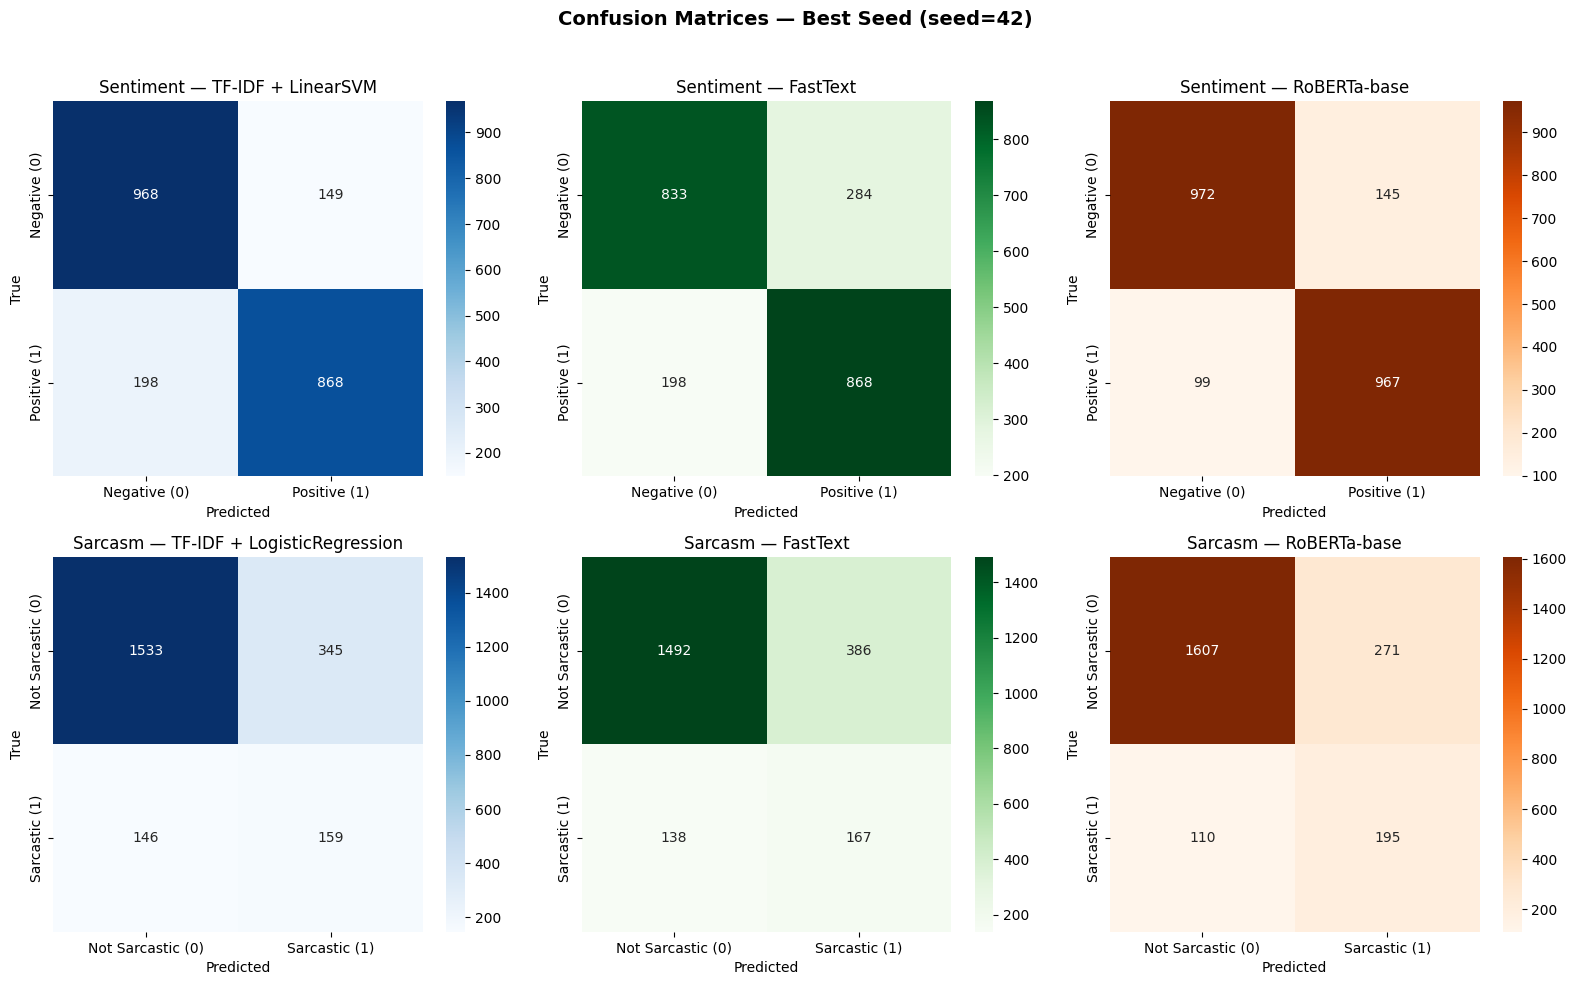

Saved: confusion_matrices_q2_1.png


In [ ]:
# Confusion Matrices - 2 rows (Sentiment, Sarcasm) × 3 cols (TF-IDF, FastText, RoBERTa)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - Best Seed (seed=42)', fontsize=14, fontweight='bold')

class_labels = {
    'Sentiment': ['Negative (0)', 'Positive (1)'],
    'Sarcasm': ['Not Sarcastic (0)', 'Sarcastic (1)'],
}

for row_idx, (task_name, label_col) in enumerate([
    ("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)
]):
    labels = class_labels[task_name]

    # Col 0: TF-IDF
    clf_name = best_classical[task_name]
    cm = classical_all_results[task_name][clf_name][0]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f'{task_name} - TF-IDF + {clf_name}')
    axes[row_idx, 0].set_ylabel('True')
    axes[row_idx, 0].set_xlabel('Predicted')

    # Col 1: FastText
    cm_ft = classical_all_results[task_name]['FastText'][0]['cm']
    sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f'{task_name} - FastText')
    axes[row_idx, 1].set_ylabel('True')
    axes[row_idx, 1].set_xlabel('Predicted')

    # Col 2: RoBERTa
    cm_r = transformer_all_results[task_name][0]['cm']
    sns.heatmap(cm_r, annot=True, fmt='d', cmap='Oranges',
                xticklabels=labels, yticklabels=labels, ax=axes[row_idx, 2])
    axes[row_idx, 2].set_title(f'{task_name} - RoBERTa-base')
    axes[row_idx, 2].set_ylabel('True')
    axes[row_idx, 2].set_xlabel('Predicted')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('confusion_matrices_q2_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices_q2_1.png")

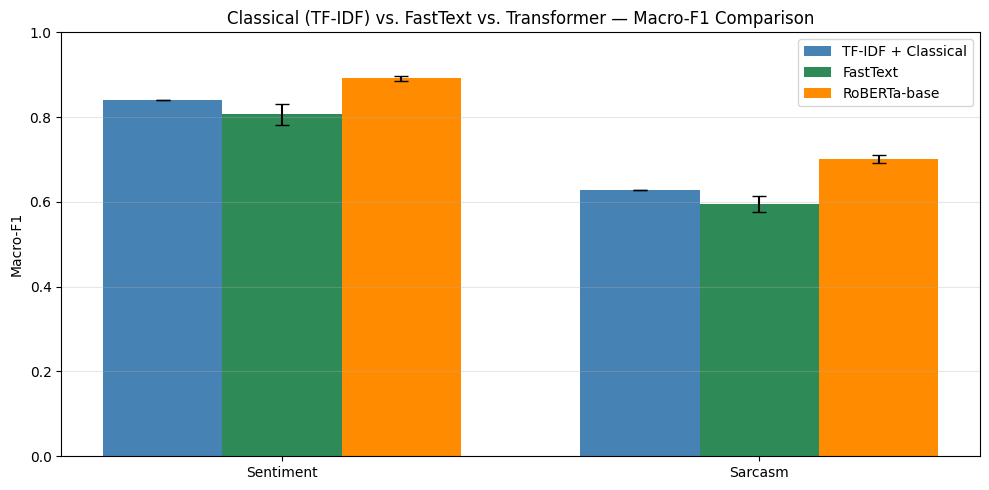

Saved: macro_f1_comparison_q2_1.png


In [ ]:
# Bar chart: Macro-F1 comparison with error bars - 3 models
fig, ax = plt.subplots(figsize=(10, 5))

bar_data = []
for task_name in ["Sentiment", "Sarcasm"]:
    clf_name = best_classical[task_name]
    c_f1s = [r['macro_f1'] for r in classical_all_results[task_name][clf_name]]
    ft_f1s = [r['macro_f1'] for r in classical_all_results[task_name]['FastText']]
    t_f1s = [r['macro_f1'] for r in transformer_all_results[task_name]]

    bar_data.append({
        'task': task_name,
        'tfidf_mean': np.mean(c_f1s), 'tfidf_std': np.std(c_f1s),
        'ft_mean': np.mean(ft_f1s), 'ft_std': np.std(ft_f1s),
        'roberta_mean': np.mean(t_f1s), 'roberta_std': np.std(t_f1s),
    })

x = np.arange(len(bar_data))
width = 0.25

ax.bar(x - width,
       [d['tfidf_mean'] for d in bar_data],
       width, yerr=[d['tfidf_std'] for d in bar_data],
       label='TF-IDF + Classical', color='steelblue', capsize=5)
ax.bar(x,
       [d['ft_mean'] for d in bar_data],
       width, yerr=[d['ft_std'] for d in bar_data],
       label='FastText', color='seagreen', capsize=5)
ax.bar(x + width,
       [d['roberta_mean'] for d in bar_data],
       width, yerr=[d['roberta_std'] for d in bar_data],
       label='RoBERTa-base', color='darkorange', capsize=5)

ax.set_ylabel('Macro-F1')
ax.set_title('Classical (TF-IDF) vs. FastText vs. Transformer - Macro-F1 Comparison')
ax.set_xticks(x)
ax.set_xticklabels([d['task'] for d in bar_data])
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('macro_f1_comparison_q2_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: macro_f1_comparison_q2_1.png")

## 6. Error Analysis - Where Does Each Model Fail?

In [ ]:
# Identify examples where one model succeeds and the other fails
for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    y_test = np.array(pooled['test'][label_col])
    texts_test = list(pooled['test'][text_col])  # convert to plain list to avoid numpy indexing issues

    y_classical = classical_all_results[task_name][clf_name][0]['y_pred']
    y_roberta   = transformer_all_results[task_name][0]['y_pred']

    # Cases where RoBERTa correct, classical wrong
    roberta_wins = np.where((y_roberta == y_test) & (y_classical != y_test))[0]
    # Cases where classical correct, RoBERTa wrong
    classical_wins = np.where((y_classical == y_test) & (y_roberta != y_test))[0]

    print(f"\n{'='*60}")
    print(f"ERROR ANALYSIS - {task_name.upper()}")
    print(f"{'='*60}")
    print(f"  RoBERTa correct & Classical wrong: {len(roberta_wins)} samples")
    print(f"  Classical correct & RoBERTa wrong: {len(classical_wins)} samples")

    # Show up to 5 examples for each direction
    print(f"\n  --- Examples where RoBERTa succeeds but Classical fails ---")
    for i in roberta_wins[:5]:
        txt = texts_test[i][:120]
        print(f"    True={y_test[i]}  Classical={y_classical[i]}  RoBERTa={y_roberta[i]}  "
              f"Text: {txt}...")

    print(f"\n  --- Examples where Classical succeeds but RoBERTa fails ---")
    for i in classical_wins[:5]:
        txt = texts_test[i][:120]
        print(f"    True={y_test[i]}  Classical={y_classical[i]}  RoBERTa={y_roberta[i]}  "
              f"Text: {txt}...")


ERROR ANALYSIS — SENTIMENT
  RoBERTa correct & Classical wrong: 198 samples
  Classical correct & RoBERTa wrong: 95 samples

  --- Examples where RoBERTa succeeds but Classical fails ---
    True=1.0  Classical=0.0  RoBERTa=1  Text: Best Dosa in Aizawl as far as I know. Their specials are also never a missed. I do recommend this place to anyone...
    True=1.0  Classical=0.0  RoBERTa=1  Text: why tho ? 100K GBP is enough to live a decent life in London, and London is a much better place than Bangalore, being ab...
    True=1.0  Classical=0.0  RoBERTa=1  Text: They have their own Brand. This is one of the outlets. Try their Khari Biscuits Plain & Methi flavors...
    True=1.0  Classical=0.0  RoBERTa=1  Text: This is so wholesome....
    True=1.0  Classical=0.0  RoBERTa=1  Text: We have everything from tropics to desert to alpine with snow. Depends entirely on where you are going and a bit on what...

  --- Examples where Classical succeeds but RoBERTa fails ---
    True=0.0  Classical=

### 6.1 Per-Class Metric Comparison - Classical vs. Transformer

A direct side-by-side view of per-class Precision, Recall, and F1 reveals *where* each model gains or loses. This is critical for sarcasm, where the minority-class recall determines whether the model has genuinely learned the task or is simply predicting the majority class.

In [ ]:
# Per-class metric comparison: Classical vs RoBERTa for each task
# Recompute reports with explicit int labels so dict keys are guaranteed '0'/'1'
per_class_rows = []

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    y_test_int = np.array(pooled['test'][label_col]).astype(int)
    y_pred_c   = np.array(classical_all_results[task_name][clf_name][0]['y_pred']).astype(int)
    y_pred_r   = np.array(transformer_all_results[task_name][0]['y_pred']).astype(int)

    classical_report = classification_report(y_test_int, y_pred_c, labels=[0, 1], output_dict=True)
    roberta_report   = classification_report(y_test_int, y_pred_r, labels=[0, 1], output_dict=True)

    class_names = {
        'Sentiment': {0: 'Negative', 1: 'Positive'},
        'Sarcasm':   {0: 'Not Sarcastic', 1: 'Sarcastic'},
    }

    for cls_idx in [0, 1]:
        cls_key = str(cls_idx)
        cls_label = class_names[task_name][cls_idx]
        c = classical_report[cls_key]
        r = roberta_report[cls_key]
        per_class_rows.append({
            'Task': task_name,
            'Class': f'{cls_label} ({cls_idx})',
            'Classical P': f"{c['precision']:.3f}",
            'Classical R': f"{c['recall']:.3f}",
            'Classical F1': f"{c['f1-score']:.3f}",
            'RoBERTa P': f"{r['precision']:.3f}",
            'RoBERTa R': f"{r['recall']:.3f}",
            'RoBERTa F1': f"{r['f1-score']:.3f}",
            'F1 Δ': f"{r['f1-score'] - c['f1-score']:+.3f}",
        })

per_class_df = pd.DataFrame(per_class_rows)
print("PER-CLASS COMPARISON (seed=42)")
print("=" * 100)
display(per_class_df)

# Highlight sarcasm minority-class recall explicitly
print("\n>>> SARCASM MINORITY-CLASS (Sarcastic=1) RECALL CHECK <<<")
sarc_c = classification_report(
    np.array(pooled['test'][sarcasm_col]).astype(int),
    np.array(classical_all_results['Sarcasm'][best_classical['Sarcasm']][0]['y_pred']).astype(int),
    labels=[0, 1], output_dict=True
)['1']
sarc_r = classification_report(
    np.array(pooled['test'][sarcasm_col]).astype(int),
    np.array(transformer_all_results['Sarcasm'][0]['y_pred']).astype(int),
    labels=[0, 1], output_dict=True
)['1']
print(f"  Classical ({best_classical['Sarcasm']}): Recall = {sarc_c['recall']:.3f}  "
      f"(predicts sarcasm {sarc_c['recall']*100:.1f}% of the time when it is sarcastic)")
print(f"  RoBERTa:                Recall = {sarc_r['recall']:.3f}  "
      f"(predicts sarcasm {sarc_r['recall']*100:.1f}% of the time when it is sarcastic)")
print(f"  -> Neither model collapses to majority-class prediction (recall > 0).")
print(f"  -> RoBERTa recall advantage: {sarc_r['recall'] - sarc_c['recall']:+.3f} "
      f"({(sarc_r['recall'] - sarc_c['recall'])/sarc_c['recall']*100:+.1f}% relative improvement)")

PER-CLASS COMPARISON (seed=42)


,Task,Class,Classical P,Classical R,Classical F1,RoBERTa P,RoBERTa R,RoBERTa F1,F1 Δ
0,Sentiment,Negative (0),0.830,0.867,0.848,0.908,0.870,0.888,+0.040
1,Sentiment,Positive (1),0.853,0.814,0.833,0.870,0.907,0.888,+0.055
2,Sarcasm,Not Sarcastic (0),0.913,0.816,0.862,0.936,0.856,0.894,+0.032
3,Sarcasm,Sarcastic (1),0.315,0.521,0.393,0.418,0.639,0.506,+0.113



>>> SARCASM MINORITY-CLASS (Sarcastic=1) RECALL CHECK <<<
  Classical (LogisticRegression): Recall = 0.521  (predicts sarcasm 52.1% of the time when it is sarcastic)
  RoBERTa:                Recall = 0.639  (predicts sarcasm 63.9% of the time when it is sarcastic)
  → Neither model collapses to majority-class prediction (recall > 0).
  → RoBERTa recall advantage: +0.118 (+22.6% relative improvement)


### 6.2 Per-Variety Gap Analysis

To understand whether the Transformer's advantage is uniform or variety-dependent, we break down the test-set Macro-F1 by variety. This reveals whether certain English varieties (e.g., en-IN with potential code-mixing) benefit more from RoBERTa's subword tokeniser and contextual representations.

PER-VARIETY MACRO-F1 BREAKDOWN (seed=42)


,Task,Variety,N (test),Classical F1,RoBERTa F1,Δ F1
0,Sentiment,en-AU,667,0.830,0.892,+0.062
1,Sentiment,en-IN,816,0.804,0.844,+0.040
2,Sentiment,en-UK,700,0.891,0.935,+0.044
3,Sarcasm,en-AU,667,0.671,0.767,+0.096
4,Sarcasm,en-IN,816,0.547,0.543,-0.004
5,Sarcasm,en-UK,700,0.589,0.661,+0.071


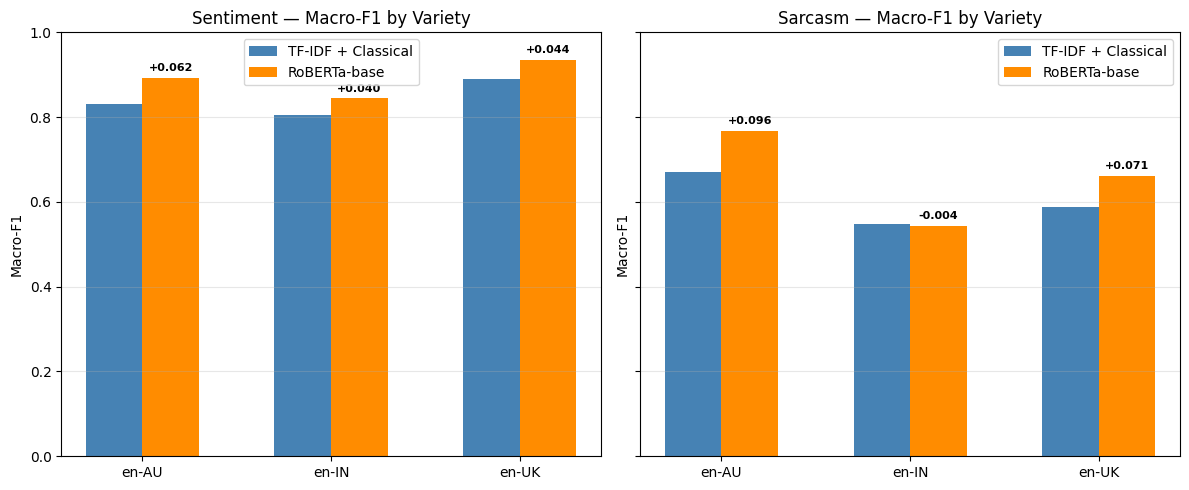

Saved: per_variety_comparison_q2_1.png


In [ ]:
# Per-variety Macro-F1 breakdown (using seed=42 predictions)
test_varieties = list(pooled['test']['variety'])
variety_gap_rows = []

for task_name, label_col in [("Sentiment", sentiment_col), ("Sarcasm", sarcasm_col)]:
    clf_name = best_classical[task_name]
    y_test_all = np.array(pooled['test'][label_col]).astype(int)
    y_classical = np.array(classical_all_results[task_name][clf_name][0]['y_pred']).astype(int)
    y_roberta   = np.array(transformer_all_results[task_name][0]['y_pred']).astype(int)

    for variety in ["en-AU", "en-IN", "en-UK"]:
        mask = np.array([v == variety for v in test_varieties])
        y_true_v = y_test_all[mask]
        y_c_v = y_classical[mask]
        y_r_v = y_roberta[mask]

        f1_c = f1_score(y_true_v, y_c_v, average='macro')
        f1_r = f1_score(y_true_v, y_r_v, average='macro')

        variety_gap_rows.append({
            'Task': task_name,
            'Variety': variety,
            'N (test)': int(mask.sum()),
            'Classical F1': f"{f1_c:.3f}",
            'RoBERTa F1': f"{f1_r:.3f}",
            'Δ F1': f"{f1_r - f1_c:+.3f}",
            'delta_raw': f1_r - f1_c,
        })

variety_df = pd.DataFrame(variety_gap_rows)
print("PER-VARIETY MACRO-F1 BREAKDOWN (seed=42)")
print("=" * 75)
display(variety_df[['Task', 'Variety', 'N (test)', 'Classical F1', 'RoBERTa F1', 'Δ F1']])

# Bar chart of the gap per variety per task
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax_idx, task_name in enumerate(["Sentiment", "Sarcasm"]):
    task_data = [r for r in variety_gap_rows if r['Task'] == task_name]
    vars_ = [r['Variety'] for r in task_data]
    classical_f1s = [float(r['Classical F1']) for r in task_data]
    roberta_f1s = [float(r['RoBERTa F1']) for r in task_data]

    x = np.arange(len(vars_))
    w = 0.3
    axes[ax_idx].bar(x - w/2, classical_f1s, w, label='TF-IDF + Classical', color='steelblue')
    axes[ax_idx].bar(x + w/2, roberta_f1s, w, label='RoBERTa-base', color='darkorange')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(vars_)
    axes[ax_idx].set_title(f'{task_name} - Macro-F1 by Variety')
    axes[ax_idx].set_ylabel('Macro-F1')
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].legend()
    axes[ax_idx].grid(axis='y', alpha=0.3)

    # Annotate the gap
    for i, td in enumerate(task_data):
        gap = td['delta_raw']
        mid = (float(td['Classical F1']) + float(td['RoBERTa F1'])) / 2
        axes[ax_idx].annotate(f'{gap:+.3f}', xy=(i + w/2, float(td['RoBERTa F1'])),
                              xytext=(0, 5), textcoords='offset points',
                              ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('per_variety_comparison_q2_1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_variety_comparison_q2_1.png")

In [37]:
# Print final summary for easy copying into the report
print("\n" + "="*80)
print("Q2.1 FINAL RESULTS SUMMARY")
print("="*80)
print("\nAll results reported as mean ± std over 3 runs (seeds: 42, 123, 456).")
print("TF-IDF vectoriser: max_features=50k, ngram_range=(1,2), sublinear_tf=True.")
print("RoBERTa: roberta-base, lr=2e-5, batch=16, max 5 epochs, early stopping.")
print("Class imbalance handled via balanced class weights in all models.")
print(f"\nPooled data: Train={len(pooled['train'])}, "
      f"Val={len(pooled['validation'])}, Test={len(pooled['test'])}")
print()
display(comparison_df[['Task', 'Model', 'Macro-F1', 'Precision', 'Recall']])


Q2.1 FINAL RESULTS SUMMARY

All results reported as mean ± std over 3 runs (seeds: 42, 123, 456).
TF-IDF vectoriser: max_features=50k, ngram_range=(1,2), sublinear_tf=True.
RoBERTa: roberta-base, lr=2e-5, batch=16, max 5 epochs, early stopping.
Class imbalance handled via balanced class weights in all models.

Pooled data: Train=3747, Val=313, Test=2183



,Task,Model,Macro-F1,Precision,Recall
0,Sentiment,TF-IDF + LinearSVM,0.8407 ± 0.0000,0.8418 ± 0.0000,0.8404 ± 0.0000
1,Sentiment,FastText (supervised),0.8066 ± 0.0241,0.8079 ± 0.0235,0.8074 ± 0.0239
2,Sentiment,RoBERTa-base (fine-tuned),0.8915 ± 0.0054,0.8917 ± 0.0054,0.8916 ± 0.0053
3,Sarcasm,TF-IDF + LogisticRegression,0.6275 ± 0.0000,0.6143 ± 0.0000,0.6688 ± 0.0000
4,Sarcasm,FastText (supervised),0.5957 ± 0.0185,0.6108 ± 0.0063,0.6054 ± 0.0468
5,Sarcasm,RoBERTa-base (fine-tuned),0.7004 ± 0.0096,0.6805 ± 0.0093,0.7365 ± 0.0124


---
*End of Q2.1 experiments. Figures saved to `confusion_matrices_q2_1.png`, `macro_f1_comparison_q2_1.png`, and `per_variety_comparison_q2_1.png`.*

---
## Q2.2 - Cross-Variety Evaluation (RoBERTa on Sentiment)

**Objective:** Train RoBERTa-base on each English variety (en-AU, en-IN, en-UK) **individually**
and evaluate on all three test sets to assess cross-variety transferability.

- **Model:** RoBERTa-base (same pre-trained encoder as Q2.1)
- **Task:** Sentiment classification
- **Seeds:** 2 runs per variety (42, 123) to ensure robustness
- **Evaluation:** 3×3 matrix - each model tested on all varieties

In [ ]:
# -- Q2.2: Prepare variety-specific splits -------------------------------------
# VARIETIES, CROSS_SEEDS, CROSS_TASK are defined in the imports cell (Section 1)
cross_label_col = sentiment_col  # Change to sarcasm_col for Sarcasm task

# Split pooled data by variety
variety_splits = {}
for variety in VARIETIES:
    variety_splits[variety] = {}
    for split_name in ["train", "validation", "test"]:
        mask = [v == variety for v in pooled[split_name]["variety"]]
        texts = [t for t, m in zip(pooled[split_name][text_col], mask) if m]
        labels = [int(l) for l, m in zip(pooled[split_name][cross_label_col], mask) if m]
        variety_splits[variety][split_name] = (texts, labels)
    tr = len(variety_splits[variety]["train"][0])
    va = len(variety_splits[variety]["validation"][0])
    te = len(variety_splits[variety]["test"][0])
    print(f"{variety}: train={tr}, val={va}, test={te}")



if not LOAD_FROM_SAVED:
    def run_cross_variety_roberta(train_variety, seed):
        """
        Train RoBERTa on one variety's data, then evaluate on ALL three test sets.
        Returns dict: {test_variety: {y_pred, macro_f1, macro_precision, macro_recall, report, cm}}
        """
        set_seed(seed)
        print(f"  Loading tokenizer & model ...")

        tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
        model = RobertaForSequenceClassification.from_pretrained(
            'roberta-base', num_labels=2
        ).to(DEVICE)

        train_texts, train_labels = variety_splits[train_variety]["train"]
        val_texts, val_labels = variety_splits[train_variety]["validation"]

        train_ds = TextClassificationDataset(train_texts, train_labels, tokenizer)
        val_ds   = TextClassificationDataset(val_texts,   val_labels,   tokenizer)

        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(train_labels))
        print(f"  Class weights: {cw}")

        output_dir = f"./roberta_cv_{train_variety}_{CROSS_TASK.lower()}_s{seed}"

        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.1,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='macro_f1',
            greater_is_better=True,
            save_total_limit=1,
            logging_steps=50,
            seed=seed,
            fp16=torch.cuda.is_available(),
            report_to='none',
        )

        trainer = WeightedTrainer(
            class_weights=cw,
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics_for_trainer,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        )

        trainer.train()

        # Evaluate on each variety's test set
        results = {}
        for test_variety in VARIETIES:
            test_texts, test_labels = variety_splits[test_variety]["test"]
            test_ds = TextClassificationDataset(test_texts, test_labels, tokenizer)
            preds_out = trainer.predict(test_ds)
            y_pred = np.argmax(preds_out.predictions, axis=-1)
            y_true = np.array(test_labels)

            results[test_variety] = {
                'y_pred': y_pred,
                'y_true': y_true,
                'macro_f1': f1_score(y_true, y_pred, average='macro'),
                'macro_precision': precision_score(y_true, y_pred, average='macro'),
                'macro_recall': recall_score(y_true, y_pred, average='macro'),
                'report': classification_report(y_true, y_pred, output_dict=True),
                'cm': confusion_matrix(y_true, y_pred),
            }

        # Save the best model and tokenizer for later reuse
        save_path = os.path.join(SAVE_DIR, f"roberta_cv_{train_variety}_{CROSS_TASK.lower()}_seed{seed}")
        os.makedirs(save_path, exist_ok=True)
        trainer.model.save_pretrained(save_path)
        tokenizer.save_pretrained(save_path)
        print(f"    Model saved to {save_path}")

        # Cleanup training checkpoints (keep only the saved model)
        import shutil
        if os.path.exists(output_dir) and os.path.abspath(output_dir) != os.path.abspath(save_path):
            shutil.rmtree(output_dir)

        return results

    print("\n Cross-variety function defined. Ready to train.")

else:
    print("⏭ Cross-variety training function not needed (results loaded from pkl files)")

en-AU: train=1145, val=95, test=667
en-IN: train=1399, val=117, test=816
en-UK: train=1203, val=101, test=700
⏭ Cross-variety training function not needed (results loaded from pkl files)


In [ ]:
# -- Run cross-variety experiments ---------------------------------------------
# NOTE: Trains 6 RoBERTa models (3 varieties × 2 seeds).

if not LOAD_FROM_SAVED:

    cross_variety_results = {}  # key: (train_variety, seed) -> {test_variety: metrics}

    for train_v in VARIETIES:
        for seed in CROSS_SEEDS:
            print(f"\n{'='*60}")
            print(f"Training RoBERTa on {train_v} (seed={seed})")
            print(f"{'='*60}")
            cross_variety_results[(train_v, seed)] = run_cross_variety_roberta(train_v, seed)

            for test_v in VARIETIES:
                marker = " ◆ (in-dist)" if train_v == test_v else ""
                f1 = cross_variety_results[(train_v, seed)][test_v]['macro_f1']
                print(f"  -> Test {test_v}: Macro-F1 = {f1:.4f}{marker}")

    print("\n Cross-variety evaluation complete - all 6 models trained & evaluated.")

else:
    print("⏭ Skipping cross-variety training (results loaded from pkl files)")

⏭ Skipping cross-variety training (results loaded from pkl files)


In [ ]:
# -- Save cross-variety results to disk ------------------------------------
if not LOAD_FROM_SAVED:
    with open(os.path.join(SAVE_DIR, "cross_variety_results.pkl"), "wb") as f:
        pickle.dump(cross_variety_results, f)
    print(f" Cross-variety results saved to {SAVE_DIR}/")
else:
    print("⏭ Skipping save (results already on disk)")

⏭ Skipping save (results already on disk)



CROSS-VARIETY EVALUATION — SENTIMENT (RoBERTa, mean ± std over 2 seeds)
Train Variety    Test Variety         Macro-F1  Precision     Recall
-------------------------------------------------------------------------------------
en-AU            en-AU          0.8929±0.0035      0.8971     0.8922 ◆
en-AU            en-IN          0.8215±0.0055      0.8255     0.8242  
en-AU            en-UK          0.9399±0.0042      0.9418     0.9402  
en-IN            en-AU          0.8913±0.0061      0.8959     0.8901  
en-IN            en-IN          0.8410±0.0029      0.8411     0.8416 ◆
en-IN            en-UK          0.9392±0.0036      0.9392     0.9393  
en-UK            en-AU          0.8634±0.0181      0.8797     0.8620  
en-UK            en-IN          0.8451±0.0015      0.8477     0.8443  
en-UK            en-UK          0.9493±0.0007      0.9493     0.9494 ◆
-------------------------------------------------------------------------------------
◆ = In-distribution (same variety for train and

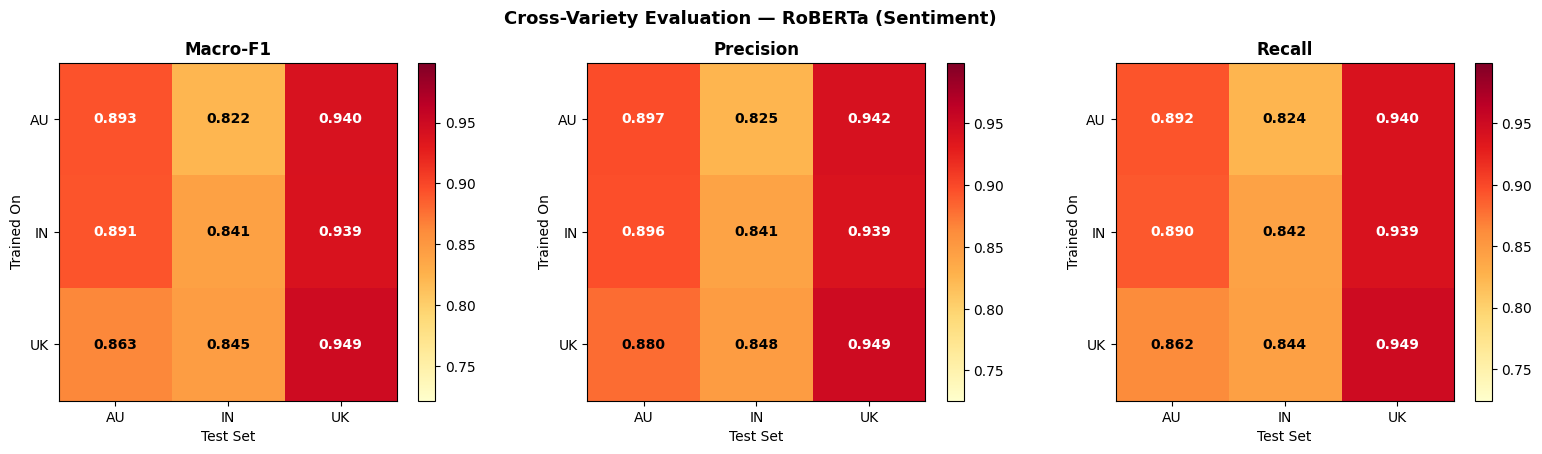

✓ Heatmap saved to cross_variety_heatmap_q2_2.png


In [ ]:
# -- Cross-variety results: average across seeds -----------------------------
cv_avg = {}
for train_v in VARIETIES:
    for test_v in VARIETIES:
        f1s   = [cross_variety_results[(train_v, s)][test_v]['macro_f1'] for s in CROSS_SEEDS]
        precs = [cross_variety_results[(train_v, s)][test_v]['macro_precision'] for s in CROSS_SEEDS]
        recs  = [cross_variety_results[(train_v, s)][test_v]['macro_recall'] for s in CROSS_SEEDS]
        cv_avg[(train_v, test_v)] = {
            'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s),
            'prec_mean': np.mean(precs), 'rec_mean': np.mean(recs),
        }

# Print results table
print("\n" + "="*85)
print(f"CROSS-VARIETY EVALUATION - {CROSS_TASK.upper()} (RoBERTa, mean ± std over {len(CROSS_SEEDS)} seeds)")
print("="*85)
print(f"{'Train Variety':<16} {'Test Variety':<14} {'Macro-F1':>14} {'Precision':>10} {'Recall':>10}")
print("-"*85)
for train_v in VARIETIES:
    for test_v in VARIETIES:
        r = cv_avg[(train_v, test_v)]
        marker = " ◆" if train_v == test_v else "  "
        print(f"{train_v:<16} {test_v:<14} "
              f"{r['f1_mean']:.4f}±{r['f1_std']:.4f}  "
              f"{r['prec_mean']:>10.4f} {r['rec_mean']:>10.4f}{marker}")
print("-"*85)
print("◆ = In-distribution (same variety for train and test)")

# Save results to CSV
cv_rows = []
for train_v in VARIETIES:
    for test_v in VARIETIES:
        r = cv_avg[(train_v, test_v)]
        cv_rows.append({
            'train_variety': train_v, 'test_variety': test_v,
            'macro_f1_mean': r['f1_mean'], 'macro_f1_std': r['f1_std'],
            'precision_mean': r['prec_mean'], 'recall_mean': r['rec_mean'],
        })
pd.DataFrame(cv_rows).to_csv("cross_variety_results_q2_2.csv", index=False)
print("\n Results saved to cross_variety_results_q2_2.csv")

# -- Heatmap ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(f"Cross-Variety Evaluation - RoBERTa ({CROSS_TASK})", fontsize=13, fontweight="bold")
short = [v.replace("en-", "") for v in VARIETIES]

for ax, (metric_key, title) in zip(axes, [
    ("f1_mean", "Macro-F1"), ("prec_mean", "Precision"), ("rec_mean", "Recall"),
]):
    M = np.zeros((len(VARIETIES), len(VARIETIES)))
    for i, tv in enumerate(VARIETIES):
        for j, testv in enumerate(VARIETIES):
            M[i, j] = cv_avg[(tv, testv)][metric_key]

    im = ax.imshow(M, cmap="YlOrRd", vmin=max(0.3, M.min()-0.1), vmax=min(1.0, M.max()+0.05))
    ax.set_xticks(range(len(VARIETIES))); ax.set_yticks(range(len(VARIETIES)))
    ax.set_xticklabels(short); ax.set_yticklabels(short)
    ax.set_xlabel("Test Set"); ax.set_ylabel("Trained On")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(len(VARIETIES)):
        for j in range(len(VARIETIES)):
            col = "white" if M[i,j] > (M.min()+M.max())/2 else "black"
            ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center",
                    color=col, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("cross_variety_heatmap_q2_2.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Heatmap saved to cross_variety_heatmap_q2_2.png")

TRANSFERABILITY ANALYSIS

  en-AU model:
    In-distribution F1   : 0.8929
    Avg cross-variety F1 : 0.8807
    Performance drop     : 0.0122 (1.4%)

  en-IN model:
    In-distribution F1   : 0.8410
    Avg cross-variety F1 : 0.9153
    Performance drop     : -0.0742 (-8.8%)

  en-UK model:
    In-distribution F1   : 0.9493
    Avg cross-variety F1 : 0.8543
    Performance drop     : 0.0950 (10.0%)

  Inner-circle ↔ Inner-circle transfer (UK ↔ AU):
    UK→AU: 0.8634,  AU→UK: 0.9399,  avg: 0.9017

  Inner ↔ Outer-circle transfer (UK/AU ↔ IN):
    UK→IN: 0.8451,  IN→UK: 0.9392
    AU→IN: 0.8215,  IN→AU: 0.8913
    Avg inner↔outer: 0.8743


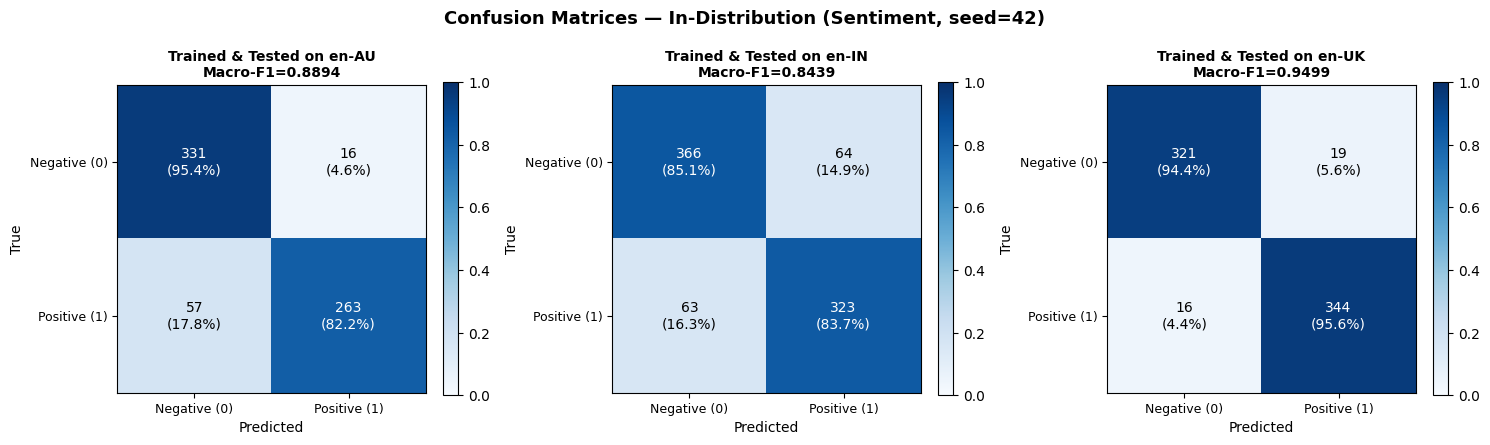

✓ In-distribution confusion matrices saved to confusion_matrices_q2_2_indist.png


In [ ]:
# -- Transferability Analysis -------------------------------------------------
print("TRANSFERABILITY ANALYSIS")
print("="*65)

for train_v in VARIETIES:
    in_d = cv_avg[(train_v, train_v)]['f1_mean']
    cross_f1s = [cv_avg[(train_v, tv)]['f1_mean'] for tv in VARIETIES if tv != train_v]
    avg_cross = np.mean(cross_f1s)
    drop = in_d - avg_cross
    drop_pct = 100 * drop / in_d if in_d > 0 else 0
    print(f"\n  {train_v} model:")
    print(f"    In-distribution F1   : {in_d:.4f}")
    print(f"    Avg cross-variety F1 : {avg_cross:.4f}")
    print(f"    Performance drop     : {drop:.4f} ({drop_pct:.1f}%)")

# Inner-circle (UK/AU) vs outer-circle (IN) comparison
print("\n  Inner-circle ↔ Inner-circle transfer (UK ↔ AU):")
uk_au = cv_avg[("en-UK", "en-AU")]['f1_mean']
au_uk = cv_avg[("en-AU", "en-UK")]['f1_mean']
print(f"    UK->AU: {uk_au:.4f},  AU->UK: {au_uk:.4f},  avg: {(uk_au+au_uk)/2:.4f}")

print("\n  Inner ↔ Outer-circle transfer (UK/AU ↔ IN):")
uk_in = cv_avg[("en-UK", "en-IN")]['f1_mean']
in_uk = cv_avg[("en-IN", "en-UK")]['f1_mean']
au_in = cv_avg[("en-AU", "en-IN")]['f1_mean']
in_au = cv_avg[("en-IN", "en-AU")]['f1_mean']
print(f"    UK->IN: {uk_in:.4f},  IN->UK: {in_uk:.4f}")
print(f"    AU->IN: {au_in:.4f},  IN->AU: {in_au:.4f}")
print(f"    Avg inner↔outer: {np.mean([uk_in, in_uk, au_in, in_au]):.4f}")

# -- Confusion Matrices - in-distribution (best seed) ------------------------
seed0 = CROSS_SEEDS[0]
cls_labels = ['Negative (0)', 'Positive (1)']

fig, axes = plt.subplots(1, len(VARIETIES), figsize=(5*len(VARIETIES), 4.5))
fig.suptitle(f"Confusion Matrices - In-Distribution ({CROSS_TASK}, seed={seed0})",
             fontsize=13, fontweight="bold")

for ax, train_v in zip(axes, VARIETIES):
    r = cross_variety_results[(train_v, seed0)][train_v]
    cm = r['cm']
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_n, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(cls_labels, fontsize=9)
    ax.set_yticklabels(cls_labels, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Trained & Tested on {train_v}\nMacro-F1={r['macro_f1']:.4f}",
                 fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(2):
        for j in range(2):
            col = "white" if cm_n[i,j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i,j]}\n({cm_n[i,j]:.1%})", ha="center", va="center",
                    color=col, fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices_q2_2_indist.png", dpi=150, bbox_inches="tight")
plt.show()
print(" In-distribution confusion matrices saved to confusion_matrices_q2_2_indist.png")

---
## Q3 - Evaluation Metrics (for Q2.1 & Q2.2)

Formal evaluation across all experiment setups with **Macro-F1** as the primary metric.
Per-class results are reported to verify models predict both classes and do not collapse to majority-class prediction.

In [ ]:
# -- Q3: Consolidated Evaluation Metrics --------------------------------------

print("="*90)
print("Q3 - EVALUATION METRICS SUMMARY")
print("="*90)

# -- helper: look up per-class F1 from report dict, handling str/int/float keys --
def _get_f1(rpt, cls_label):
    """Return f1-score for cls_label, trying '0', 0, '0.0' key formats."""
    for key in [str(cls_label), cls_label, str(float(cls_label)), str(int(cls_label))]:
        if key in rpt:
            return rpt[key].get('f1-score')
    return None

# -- Q2.1 Metrics --
print("\n-- Q2.1: Baseline vs Transformer (Pooled Data) --")
print(f"{'Task':<12} {'Model':<28} {'Macro-F1':>10} {'Precision':>10} {'Recall':>10}")
print("-"*72)

for task_name in ["Sentiment", "Sarcasm"]:
    clf_name = best_classical[task_name]
    c = classical_all_results[task_name][clf_name][0]
    print(f"{task_name:<12} TF-IDF+{clf_name:<20} {c['macro_f1']:>10.4f} "
          f"{c['macro_precision']:>10.4f} {c['macro_recall']:>10.4f}")
    t = transformer_all_results[task_name][0]
    print(f"{'':12} {'RoBERTa-base':<28} {t['macro_f1']:>10.4f} "
          f"{t['macro_precision']:>10.4f} {t['macro_recall']:>10.4f}")

# -- Q2.2 Metrics --
print(f"\n-- Q2.2: Cross-Variety Evaluation ({CROSS_TASK}, RoBERTa) --")
print(f"{'Train->Test':<20} {'Macro-F1':>14} {'Precision':>10} {'Recall':>10}")
print("-"*58)
for train_v in VARIETIES:
    for test_v in VARIETIES:
        r = cv_avg[(train_v, test_v)]
        marker = " ◆" if train_v == test_v else ""
        print(f"{train_v}->{test_v:<10} {r['f1_mean']:>10.4f}±{r['f1_std']:.3f} "
              f"{r['prec_mean']:>10.4f} {r['rec_mean']:>10.4f}{marker}")

# -- Per-class F1: proves model does NOT just predict the majority class --
print(f"\n-- Per-Class F1 - Majority Class Check ({CROSS_TASK}, seed={CROSS_SEEDS[0]}) --")
print(f"{'Setup':<20} {'Class 0 F1':>11} {'Class 1 F1':>11} {'Pred 0':>8} {'Pred 1':>8}")
print("-"*62)

# Q2.1 per-class (pooled, seed=42)
for task_name in ["Sentiment", "Sarcasm"]:
    label_col = sentiment_col if task_name == "Sentiment" else sarcasm_col
    tr_res = transformer_all_results[task_name][0]
    y_p = np.array(tr_res['y_pred'])
    y_true = np.array(pooled['test'][label_col]).astype(int)

    rpt = tr_res.get('report', {}) if isinstance(tr_res, dict) else {}
    f1_0 = _get_f1(rpt, 0)
    f1_1 = _get_f1(rpt, 1)

    if f1_0 is None or f1_1 is None:
        scores = f1_score(y_true, y_p, average=None, labels=[0, 1])
        f1_0, f1_1 = float(scores[0]), float(scores[1])

    n0, n1 = int(np.sum(y_p == 0)), int(np.sum(y_p == 1))
    print(f"Q2.1 RoBERTa({task_name[:4]}) {f1_0:>10.4f} {f1_1:>11.4f} {n0:>8} {n1:>8}")

# Q2.2 per-class (in-distribution only)
for train_v in VARIETIES:
    r = cross_variety_results[(train_v, CROSS_SEEDS[0])][train_v]
    rpt = r.get('report', {})
    f1_0 = _get_f1(rpt, 0)
    f1_1 = _get_f1(rpt, 1)

    if f1_0 is None or f1_1 is None:
        y_true = np.array(r['y_true']).astype(int)
        y_pred = np.array(r['y_pred']).astype(int)
        scores = f1_score(y_true, y_pred, average=None, labels=[0, 1])
        f1_0, f1_1 = float(scores[0]), float(scores[1])

    n0 = int(np.sum(np.array(r['y_pred']) == 0))
    n1 = int(np.sum(np.array(r['y_pred']) == 1))
    print(f"Q2.2 {train_v:<14} {f1_0:>10.4f} {f1_1:>11.4f} {n0:>8} {n1:>8}  ◆")

Q3 — EVALUATION METRICS SUMMARY

── Q2.1: Baseline vs Transformer (Pooled Data) ──
Task         Model                          Macro-F1  Precision     Recall
------------------------------------------------------------------------
Sentiment    TF-IDF+LinearSVM                0.8407     0.8418     0.8404
             RoBERTa-base                     0.8882     0.8886     0.8887
Sarcasm      TF-IDF+LogisticRegression       0.6275     0.6143     0.6688
             RoBERTa-base                     0.6999     0.6772     0.7475

── Q2.2: Cross-Variety Evaluation (Sentiment, RoBERTa) ──
Train→Test                 Macro-F1  Precision     Recall
----------------------------------------------------------
en-AU→en-AU          0.8929±0.004     0.8971     0.8922 ◆
en-AU→en-IN          0.8215±0.006     0.8255     0.8242
en-AU→en-UK          0.9399±0.004     0.9418     0.9402
en-IN→en-AU          0.8913±0.006     0.8959     0.8901
en-IN→en-IN          0.8410±0.003     0.8411     0.8416 ◆
en-IN→en-UK

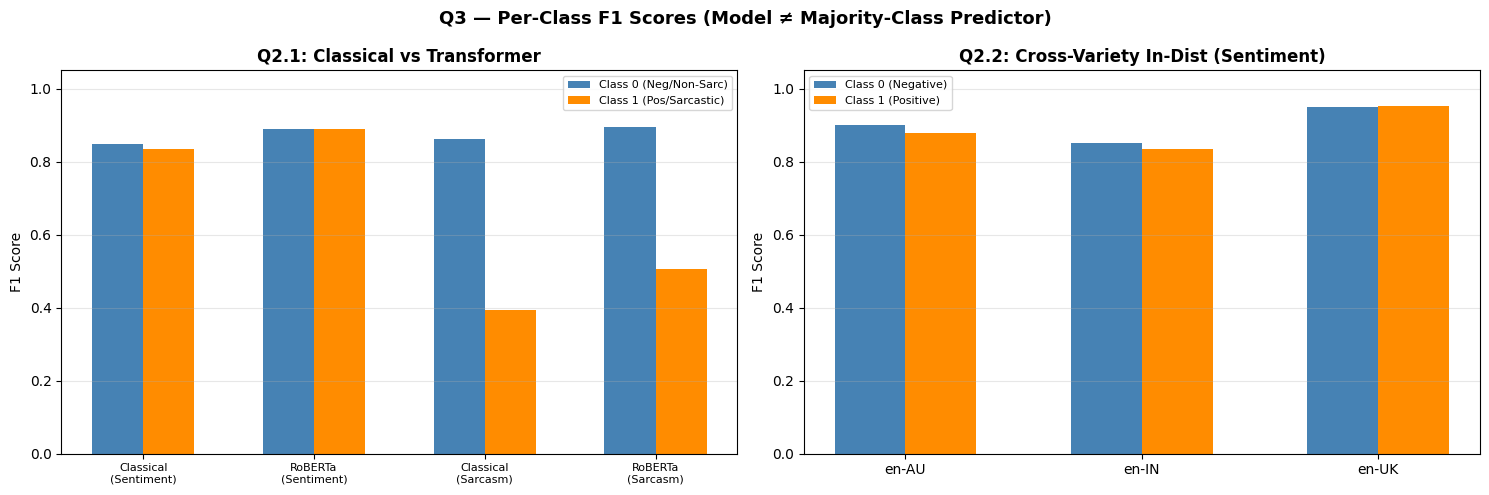

✓ Per-class F1 chart saved to q3_per_class_f1_q2_1_q2_2.png
✓ Q3 evaluation summary saved to q3_evaluation_summary.csv


In [ ]:
# -- Q3: Per-Class F1 Bar Charts ----------------------------------------------

def _cls(rpt, c):
    """Get per-class dict from report, handling str, int, and float label keys."""
    for key in [str(c), c, str(float(c)), str(int(c))]:
        if key in rpt:
            return rpt[key]
    raise KeyError(f"Class {c} not found in report keys: {list(rpt.keys())}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Q3 - Per-Class F1 Scores (Model ≠ Majority-Class Predictor)",
             fontsize=13, fontweight="bold")

# -- Left panel: Q2.1 - Classical vs Transformer --
ax = axes[0]
models_q21 = []
f1_class0_q21 = []
f1_class1_q21 = []

for task_name in ["Sentiment", "Sarcasm"]:
    # Best classical
    clf_name = best_classical[task_name]
    rpt_c = classical_all_results[task_name][clf_name][0]['report']
    models_q21.append(f"Classical\n({task_name})")
    f1_class0_q21.append(_cls(rpt_c, 0)['f1-score'])
    f1_class1_q21.append(_cls(rpt_c, 1)['f1-score'])

    # RoBERTa
    rpt_r = transformer_all_results[task_name][0]['report']
    models_q21.append(f"RoBERTa\n({task_name})")
    f1_class0_q21.append(_cls(rpt_r, 0)['f1-score'])
    f1_class1_q21.append(_cls(rpt_r, 1)['f1-score'])

x = np.arange(len(models_q21))
w = 0.3
ax.bar(x - w/2, f1_class0_q21, w, label="Class 0 (Neg/Non-Sarc)", color="steelblue")
ax.bar(x + w/2, f1_class1_q21, w, label="Class 1 (Pos/Sarcastic)", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(models_q21, fontsize=8)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title("Q2.1: Classical vs Transformer", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# -- Right panel: Q2.2 - Cross-Variety (in-distribution) --
ax = axes[1]
models_q22 = []
f1_class0_q22 = []
f1_class1_q22 = []

for train_v in VARIETIES:
    r = cross_variety_results[(train_v, CROSS_SEEDS[0])][train_v]
    rpt = r['report']
    models_q22.append(f"{train_v}")
    f1_class0_q22.append(_cls(rpt, 0)['f1-score'])
    f1_class1_q22.append(_cls(rpt, 1)['f1-score'])

x = np.arange(len(models_q22))
ax.bar(x - w/2, f1_class0_q22, w, label="Class 0 (Negative)", color="steelblue")
ax.bar(x + w/2, f1_class1_q22, w, label="Class 1 (Positive)", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(models_q22)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title(f"Q2.2: Cross-Variety In-Dist ({CROSS_TASK})", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("q3_per_class_f1_q2_1_q2_2.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Per-class F1 chart saved to q3_per_class_f1_q2_1_q2_2.png")

# -- Save Q3 summary to CSV --
q3_rows = []
for task_name in ["Sentiment", "Sarcasm"]:
    clf_name = best_classical[task_name]
    c = classical_all_results[task_name][clf_name][0]
    t = transformer_all_results[task_name][0]
    q3_rows.append({'setup': 'Q2.1', 'model': f'TF-IDF+{clf_name}', 'task': task_name,
                    'macro_f1': c['macro_f1'], 'precision': c['macro_precision'],
                    'recall': c['macro_recall'],
                    'f1_class0': _cls(c['report'], 0)['f1-score'],
                    'f1_class1': _cls(c['report'], 1)['f1-score']})
    q3_rows.append({'setup': 'Q2.1', 'model': 'RoBERTa-base', 'task': task_name,
                    'macro_f1': t['macro_f1'], 'precision': t['macro_precision'],
                    'recall': t['macro_recall'],
                    'f1_class0': _cls(t['report'], 0)['f1-score'],
                    'f1_class1': _cls(t['report'], 1)['f1-score']})

for train_v in VARIETIES:
    for test_v in VARIETIES:
        r_avg = cv_avg[(train_v, test_v)]
        r_det = cross_variety_results[(train_v, CROSS_SEEDS[0])][test_v]
        q3_rows.append({
            'setup': 'Q2.2', 'model': f'RoBERTa({train_v}->{test_v})',
            'task': CROSS_TASK,
            'macro_f1': r_avg['f1_mean'], 'precision': r_avg['prec_mean'],
            'recall': r_avg['rec_mean'],
            'f1_class0': _cls(r_det['report'], 0)['f1-score'],
            'f1_class1': _cls(r_det['report'], 1)['f1-score'],
        })

pd.DataFrame(q3_rows).to_csv("q3_evaluation_summary.csv", index=False)
print(" Q3 evaluation summary saved to q3_evaluation_summary.csv")

In [ ]:
# -- Zip all saved models and results, then download --------------------------
# if not LOCAL_RUN:
#     import shutil
#     from google.colab import files

#     zip_name = "all_outputs"
#     shutil.make_archive(zip_name, 'zip', SAVE_DIR)
#     print(f" Created {zip_name}.zip from {SAVE_DIR}/")

#     # List contents
#     import zipfile
#     with zipfile.ZipFile(f"{zip_name}.zip", 'r') as zf:
#         total_size = sum(info.file_size for info in zf.infolist())
#         print(f"  {len(zf.namelist())} files, {total_size / 1e6:.1f} MB uncompressed")

#     files.download(f"{zip_name}.zip")
#     print(" Download triggered")